## Модель предсказания вероятности клика пользователя на рекламное объявление

### Описание бизнес-контекста

Компания advandex сталкивается с проблемами на высококонкурентном рынке AdTeh платформ. Она выступает как биржа между рекламодателями и издателями (площадками), которые показывают рекламу.

Кратко опишем механику взаимодействия сторон в рекламном бизнесе.

Когда пользователи заходят на площадку (сайт или приложение), на старнице формируется рекламный слот - место для отображения рекламы. Чтобы заполнить этот слот рекламная платформа получает информацию о контексте пользователя (характеристики устройства, адрес площадки и д.р.) и осуществляет поиск наиболее подхдящего рекламного объявления для пользователя. Для каждого объявления предсказывается вероятность клика объявления по признакам пользователя и его контекста. По предсказанной вероятности платформа рассчитывает ожидаемую выгоду, умножая вероятность клика на стоимость, которую заплатит рекламодатель (рекламную ставку). Наиболее выгодное объявление отправляется как предложение для издателю. Издатель, получив предложения от нескольких рекламных платформ, выбирает лучшее и размещает рекламное объявление на свое площадке.

В рассмотренном процессе важно корректно рассчитывать ожидаемую выгоду и в свою очередь предсказывать настоящую вероятность клика, которая соответствовала бы действительному поведению пользователя при взаимодействии с объявлением.

Компания advandex предоставил датасет, в котором сгруппированы пользовательские события и взаимодействие с различными рекламными объявлениями. В числе столбцов с различными признаками контекста и пользователя, присутствует результат взаимодействия пользователя с объявлением: было ли объявление кликнуто или нет.

### Цель исследования

Построить модель машинного обучения, которая будет предсказывать вероятность клика рекламного объявления по признакам пользователя, его контекста и рекламного объявления.



### Постановка ML задачи

Целевая переменная в предоставленном датасете - флаг клика пользователя:
- 1 в случае клика на объявления
-  0 в случае отсутствия клика.

Таким образом решаем задачу бинарной классификации.

Необходимо предсказать целевую переменную, причем, нужно дать вероятностную оценку клику на объявление в диапазоне от 0 до 1 для того, чтобы в дальнейшем была возможность отранжировать объявления по ожидаемой выручке, которая вычисляется как `bid x prob_click`.

Где
- bid - это рекламная ставка объявления, выставленная рекламодателем за переход по ссылке в объявлении, то есть за клик.
- prob_click - вероятность клика на объявление, предсказанная моделью.

Также необходимо интерпретировать полученные вероятности и указывать, какие факторы повлияли на результат, то есть модель должна быть интерпретируемой.

Для построения модели используется обучение с учителем. В качестве модели машинного обучения - SupportVectorMachine (SVM).

В качестве основных метрик, по которым будет проводится оценка качества модели:

- PR-AUC для учета дисбаланса положительного и отрицательного классов
- LogLoss оценит точность предсказанных вероятностей
- Brier - для оценки качества калибровки вероятностей модели

Также будут использованы вспомогательные метрики:
- Precision, Recall, F1-score - для оценки точности и полноты модели а также для сбалансированной оценки обеих метрик.

Метрик Accurancy отвергается, так как она не учитывает занчительный дисбаланс классов.

На входе в модель - набор признаков пользователя с контекстом вызова (площадка, тематика) и признаков рекламного объявления для оценки.
На выходе модели - калиброванная вероятность клика на объявление, то есть такая вероятность, которая соответствует фактическому показателю CTR (ClickThroughRate - доли кликов) для целевой переменной.

### Содержание проекта



1. <a href="#preparation">Подотовка данных</a>
1. <a href="#eda">Исследовательский анализ данных</a>
1. <a href="#train-test-split">Разделение датасета</a>
1. <a href="#preprocessing">Предобработка датасета</a>
1. <a href="#feature-selection">Отбор признаков</a>
1. <a href="#baseline">Обучение baseline модели</a>
1. <a href="#hyperparameters">Подбор гиперпараметров</a>
1. <a href="#final-model">Обучение и проверка финальной модели</a>
1. <a href="#calibration">Калибровка вероятностей</a>
1. <a href="#calibration-testing">Провека калибровки вероятностей</a>
1. <a href="#final-report">Выводы исследования</a>
1. <a href="#save-model">Персистенция модели</a>

<a id="preparation"></a>


## 1. Подготовка среды и загрузка данных

В случае запуска тетрадки в облаке, установим необходимые библиотеки:

In [1]:
!pip install -q phik==0.12.5
!pip install -q joblib==1.5.3
!pip install -q scikit-learn==1.6.1
!pip install -q category_encoders

Импортируем необходимые библиотеки:

In [2]:
import os
import requests
from datetime import datetime
from time import time
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import FunctionTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import RFE
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.calibration import calibration_curve, CalibrationDisplay
from sklearn.calibration import CalibratedClassifierCV

from scipy.stats import uniform, loguniform
from phik import phik_matrix


Зафиксируем random state для воспроизводимости результатов:

In [3]:
RANDOM_STATE = 153
np.random.seed(RANDOM_STATE)

Настроим отображение результатов выполнения ячеек в ноутбуке:

In [4]:
pd.set_option('display.max_columns', None) # выводить все колонки
pd.set_option('display.max_colwidth', 500) # выводить больше символов в ячейке



Загрузим датасет:

In [5]:
def load_dataset(
    dataset_url,
    local_file,
    local_path='datasets',
    sep=',',
    decimal='.'
):
    local_dataset_file = f'{local_path}/{local_file}'
    remote_dataset_url = dataset_url
    def read_dataset_csv():
        return pd.read_csv(local_dataset_file, sep=sep, decimal=decimal)

    try:
        df = read_dataset_csv()
        print(f'Датасет успешно загружен из {local_dataset_file}')
    except FileNotFoundError:
        os.makedirs(local_path, exist_ok=True)
        print(f'Файл не найден. Загружаем файл в {local_dataset_file} из {remote_dataset_url}')
        response = requests.get(remote_dataset_url)
        if response.status_code == 200:
            with open(local_dataset_file, 'wb') as f:
                f.write(response.content)
            print(f'Файл с датасетом успешно загружен в {local_dataset_file}')
            df = read_dataset_csv()
        else:
            raise NetworkError(f'Ошибка при загрузке файла: {response.status_code}')

    print(f'Размер загруженного датасета: {df.shape[0]} строк, {df.shape[1]} столбцов', )
    return df

df = load_dataset(
    dataset_url='https://code.s3.yandex.net/data-scientist/ds_s16_ad_click_dataset.csv',
    local_file='ds_s16_ad_click_dataset.csv'
)

Датасет успешно загружен из datasets/ds_s16_ad_click_dataset.csv
Размер загруженного датасета: 50000 строк, 34 столбцов


Файл загружен успешно и в дальнейшем при перезапуске будет использована локальная копия из каталога datasets.

<a id="eda"></a>

## 2. Исследовательский анализ данных (EDA)

#### 2.1 Базовая информацию о датасете

In [6]:
# отладочный датасет
# df = df.sample(n=int(df.shape[0]*0.33), random_state=RANDOM_STATE)

Проведем предварительный анализ загруженных данных:

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  str    
 6   site_domain       50000 non-null  str    
 7   site_category     50000 non-null  str    
 8   app_id            50000 non-null  str    
 9   app_domain        50000 non-null  str    
 10  app_category      50000 non-null  str    
 11  device_id         50000 non-null  str    
 12  device_ip         50000 non-null  str    
 13  device_model      50000 non-null  str    
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               50000 non-null  int64  
 17  C15 

В датасете присутствует 50к строк в 34 столбцах, он занимает 13 МБ в памяти. Размер небольшой, поэтому целесообразность уменьшения размерности типов данных столбцов неоправдана.

Множество столбцов представяют следующие признаки:
```

0   id                float64   - уникальный идентификатор записи о показе баннера
1   click             int64     - бинарный признак, указывающий, был ли совершён клик по баннеру. 1 — клик был, 0 — клика не было
2   hour              int64     - час, в который был показан баннер, в формате YYMMDDHH
3   C1                int64     - анонимизированный признак, характеризующий контекст показа
4   banner_pos        int64     - позиция баннера на веб-странице
5   site_id           str       - идентификатор веб-сайта, на котором был показан баннер
6   site_domain       str       - домен веб-сайта
7   site_category     str       - тематическая категория веб-сайта
8   app_id            str       - идентификатор рекламируемого мобильного приложения
9   app_domain        str       - домен рекламируемого приложения
10  app_category      str       - категория рекламируемого приложения
11  device_id         str       - идентификатор браузера или устройства
12  device_ip         str       - IP-адрес устройства
13  device_model      str       - модель устройства
14  device_type       int64     - тип устройства пользователя: например, смартфон, планшет, ПК, представлены в числовом виде [1, 5, 4, 0]
15  device_conn_type  int64     - тип сетевого соединения устройства: например, Wi-Fi, 3G, 4G, представлены в числовом виде [0, 2, 3, 5]
16  C14               int64     - группа анонимизированных признаков, описывающих параметры баннера, пользователя или аукциона
17  C15               int64     - группа анонимизированных признаков, описывающих параметры баннера, пользователя или аукциона
18  C16               int64     - группа анонимизированных признаков, описывающих параметры баннера, пользователя или аукциона
19  C17               int64     - группа анонимизированных признаков, описывающих параметры баннера, пользователя или аукциона
20  C18               int64     - группа анонимизированных признаков, описывающих параметры баннера, пользователя или аукциона
21  C19               int64     - группа анонимизированных признаков, описывающих параметры баннера, пользователя или аукциона
22  C20               int64     - группа анонимизированных признаков, описывающих параметры баннера, пользователя или аукциона
23  C21               int64     - группа анонимизированных признаков, описывающих параметры баннера, пользователя или аукциона
24  ml_feature_1      float64   - числовые признаки, полученные в результате предварительной обработки и генерации новых признаков
25  ml_feature_2      str       - категориальные признаки, полученные в результате предварительной обработки и генерации новых признаков
26  ml_feature_3      float64   - числовые признаки, полученные в результате предварительной обработки и генерации новых признаков
27  ml_feature_4      int64     - категориальные признаки, полученные в результате предварительной обработки и генерации новых признаков
28  ml_feature_5      float64   - числовые признаки, полученные в результате предварительной обработки и генерации новых признаков
29  ml_feature_6      float64   - числовые признаки, полученные в результате предварительной обработки и генерации новых признаков
30  ml_feature_7      str       - категориальные признаки, полученные в результате предварительной обработки и генерации новых признаков
31  ml_feature_8      float64   - числовые признаки, полученные в результате предварительной обработки и генерации новых признаков
32  ml_feature_9      float64   - числовые признаки, полученные в результате предварительной обработки и генерации новых признаков
33  ml_feature_10     float64   - числовые признаки, полученные в результате предварительной обработки и генерации новых признаков
```

Все признаки соответствуют описанию, переданному аналитиком advandex и представляют из себя несколько групп. Часть признаков передана в обезличенном (захэшированном) виде, таким образом по значениям признака затруднительно восстановить исходное значение, но это не помешает исследованию, так как признаки должны быть все равно преобразованы в числовой формат для цели обучения модели машинного обучения.

Оценим количество пропусков:

In [8]:
def na_info(df, round_digits=1):
    '''
    Возвращает таблицу с количеством и процентом пропусков в столбцах датасета.
    '''
    count_na_name = 'Количество пропусков'
    res = pd.DataFrame({
        'Количество строк': len(df),
        count_na_name: df.isna().sum(),
        'Процент пропусков': round(df.isna().mean()*100, round_digits)
    }).sort_values(by=count_na_name, ascending=False)
    return res.query(f'`{count_na_name}` > 0').reset_index()

na_info(df)

,index,Количество строк,Количество пропусков,Процент пропусков


Пропуски в данных отсутствуют.

Оценим содержимое таблицы, выбрав строки из начала, из произвольных мест и из конца датасета:

In [9]:
pd.concat([
    df.head(5),
    df.sample(5, random_state=RANDOM_STATE),
    df.tail(5),
]).sort_index()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,488a9a3e,31025cda,1,0,17614,320,50,1993,2,1063,-1,33,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,75bb1b58,2ee63ff8,1,0,15701,320,50,1722,0,35,-1,79,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,285263b0,d780319b,1,0,17914,320,50,2043,2,39,100084,32,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,0f2161f8,a99f214a,18190986,f4fffcd0,1,0,21611,320,50,2480,3,297,100111,61,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,b66e5482,a0f5f879,1,0,15702,320,50,1722,0,35,100084,79,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909
5404,5.046578e+18,0,14102202,1005,1,e151e245,7e091613,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,bbf89d28,b4e612c1,1,0,21675,320,50,2495,2,167,-1,23,-0.370930,E,-1.411053,0,0.623068,-0.075684,Y,-0.401251,-0.305800,0.256195
8832,1.441314e+19,0,14102212,1005,0,85f751fd,c4e18dd6,50e219e0,e9739828,df32afa9,cef3e649,a99f214a,5389afc6,a0f5f879,1,0,21770,320,50,2507,0,35,100176,157,1.390151,D,-4.452716,1,0.568877,-0.627813,Y,-0.138210,-0.341709,-0.035219
9602,8.616159e+18,0,14102213,1005,0,5bcf81a2,9d54950b,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,6cf2ad84,cd5b1559,1,2,21767,320,50,2506,0,35,100111,157,-0.396663,A,-9.939108,0,0.412667,0.434229,X,0.460987,0.677666,0.321686
37574,4.838543e+18,0,14102814,1005,0,85f751fd,c4e18dd6,50e219e0,73206397,2347f47a,8ded1f7a,91e808bf,a80951de,05b9fa1b,1,0,23144,320,50,2665,0,35,-1,221,0.115515,D,2.228141,1,1.530277,0.875605,Z,0.188147,-0.169379,0.435325
48054,1.051790e+19,0,14103014,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,1ecb5228,d787e91b,1,0,22254,320,50,2545,0,431,100084,221,0.862208,C,-9.148074,0,-2.328464,0.502994,Z,-0.326937,-0.632825,0.031190


Обращают на себя внимание столбцы:
- C1, device-type, С15, C16,  - похоже, что он константный или квази-константный
- device-type - тоже похоже на константный или квази-константный

Остальные значения пока не вызывают подозрения. Возможно некоторые из них будут отброшены из датасета после EDA.

Оценим описательную статистику датасета:

In [10]:
custom_percentiles = [0.25, 0.5, 0.75, 0.95, 0.99]
df.describe(percentiles=custom_percentiles)

,id,click,hour,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21,ml_feature_1,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10
count,5.000000e+04,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,9.215402e+18,0.172060,1.410256e+07,1004.970060,0.291380,1.018120,0.337160,18826.648680,318.86640,59.692480,2109.781020,1.428100,227.703800,53173.383240,83.685180,-0.002445,-0.036381,0.498040,0.034729,0.022948,0.025465,0.035361,0.020226
std,5.328516e+18,0.377436,2.967892e+02,1.110202,0.514201,0.538477,0.860057,4983.064178,20.56153,46.720842,612.963141,1.327413,351.592108,49960.181871,70.539513,1.000280,5.792335,0.500001,1.002116,0.656690,0.578026,0.505034,0.303309
min,3.191077e+13,0.000000,1.410210e+07,1001.000000,0.000000,0.000000,0.000000,375.000000,120.00000,20.000000,112.000000,0.000000,33.000000,-1.000000,13.000000,-4.631262,-9.999742,0.000000,-4.631853,-1.000000,-0.999965,-2.147526,-1.287965
25%,4.580649e+18,0.000000,1.410230e+07,1005.000000,0.000000,1.000000,0.000000,16920.000000,320.00000,50.000000,1823.000000,0.000000,35.000000,-1.000000,23.000000,-0.677784,-5.059555,0.000000,-0.639829,-0.579775,-0.470627,-0.304077,-0.182386
50%,9.243015e+18,0.000000,1.410260e+07,1005.000000,0.000000,1.000000,0.000000,20346.000000,320.00000,50.000000,2323.000000,2.000000,39.000000,100049.000000,61.000000,-0.003776,-0.056155,0.000000,0.028112,0.037786,0.027348,0.035985,0.018930
75%,1.380920e+19,0.000000,1.410281e+07,1005.000000,1.000000,1.000000,0.000000,21916.000000,320.00000,50.000000,2526.000000,3.000000,171.000000,100094.000000,108.000000,0.673534,4.985939,1.000000,0.707594,0.637131,0.521117,0.374152,0.224080
95%,1.752879e+19,1.000000,1.410301e+07,1005.000000,1.000000,1.000000,3.000000,23561.050000,320.00000,50.000000,2691.000000,3.000000,1063.000000,100191.000000,221.000000,1.644342,9.021195,1.000000,1.686860,0.980061,0.922017,0.866824,0.516719
99%,1.825989e+19,1.000000,1.410302e+07,1010.000000,1.000000,4.000000,3.000000,23866.000000,320.00000,250.000000,2736.000000,3.000000,1327.000000,100210.000000,229.000000,2.335170,9.805364,1.000000,2.358373,0.999283,1.003873,1.213255,0.726487
max,1.844652e+19,1.000000,1.410302e+07,1012.000000,7.000000,5.000000,5.000000,24043.000000,1024.00000,1024.000000,2757.000000,3.000000,1839.000000,100248.000000,255.000000,3.793828,9.999975,1.000000,4.230623,1.000000,1.119858,2.120786,1.202300


По представленным данным можно сделать вывод:
- id - идентификатор, его можно будет удалить из обучающего датасета
- мы имеем дело с дисбалансом классов, так как положительный класс встречается только в 17% объектов, о чем говорит mean для столбца click
- Столбец hour представляет собой дату и время, поэтому лучше использовать тип данных datetime. Вообще говоря час показа рекламы может влиять на целевую переменную. Так как мы не рассматриваем в данной работе временные ряды, то информация о дате является излишней. Следует оставить только данные о часе, отбросив дату
- C1 имеет малое отклонение и похож на квази-константный столбец
- banner_pos имеет значения от 0 до 7, медианное значение - 0, 75 процентиль - 1. То есть баннеры располагаются преимущественно на 0 и 1 позициях.
- device_type преимущественно имеет значение 1 (скорее всего mobile) - кандидат на отбор признака
- device_conn_type - тоже почти все значения = 0 - кандидат на отбор
- C15, C16, C18, ml_feature_4 - аналогично, большинство значений константы - похоже на квази переменные

In [11]:
dt_format = '%y%m%d%H'
min_date = pd.to_datetime(df['hour'].min(), format=dt_format)
max_data = pd.to_datetime(df['hour'].max(), format=dt_format)
diff_date = max_data - min_date
print(diff_date)


9 days 23:00:00


Данные в представленном датасете собраны за 10 дней.

Столбец hour преобразуем из даты со временем в столбец более отвечающий названию - отбросим дату и оставим только значения часа 00..23, оно может теоретически давать профит при обучении.

In [12]:
def to_hour(date):
    return pd.to_datetime(date, format=dt_format).hour
df['hour'] = df['hour'].apply(to_hour)

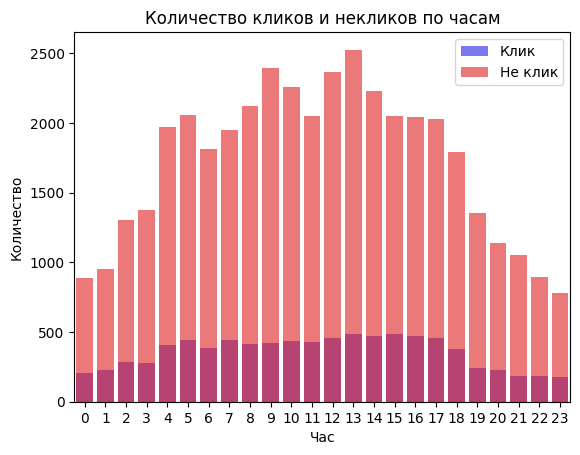

In [13]:
aggregated_df = df.groupby('hour')['click'].value_counts().unstack().reset_index()
aggregated_df.columns = ['hour', 'non_clicks', 'clicks']

sns.barplot(data=aggregated_df, x='hour', y='clicks', color='blue', alpha=0.6, label='Клик')
sns.barplot(data=aggregated_df, x='hour', y='non_clicks', color='red', alpha=0.6, label='Не клик')

plt.legend()
plt.title('Количество кликов и некликов по часам')
plt.xlabel('Час')
plt.ylabel('Количество')
plt.show()

Теперь мы имеем столбец hour - в котором присутствует только час без даты.

По диграмме видно, что наименьшая активность в рекламных событиях - ночь.

#### 2.2 Анализ целевой переменной


In [14]:
# определим переменную с названием target-столбца
TARGET='click'

In [15]:
df[TARGET].value_counts(normalize=True)

click
0    0.82794
1    0.17206
Name: proportion, dtype: float64

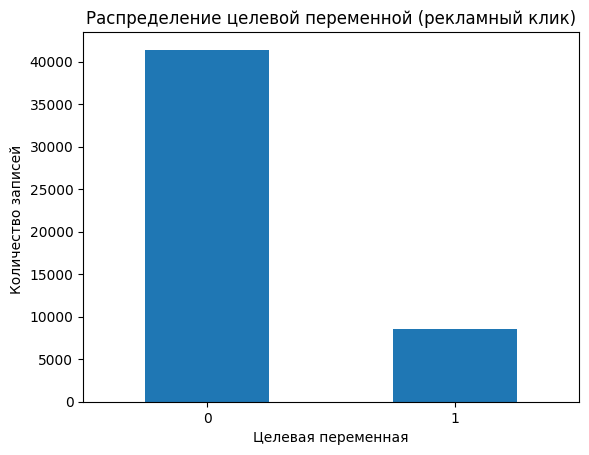

In [16]:
df[TARGET].value_counts(normalize=False).plot(
    kind='bar',
    title='Распределение целевой переменной (рекламный клик)',
    xlabel='Целевая переменная',
    ylabel='Количество записей ',
    rot=0,
)
plt.show()

График подтверждает, что датасет имеет несбалансированную целевую переменную: 17% - положительный класс (клик по рекламе), остальное - отрицательный класс.

#### 2.3 Анализ признаков




Удалим явно ненужные столцы, которые по определению не помогуть при обучении модели:
- id - уникальный идентификатор записи о показе баннера
- device_id - идентификатор браузера или устройства, он уникален для конкретного пользователя или устройства и не может быть использован для обучения
- device_ip - IP-адрес устройства - технический столбец, сетевой адрес тоже не может быть учтен в обучении



In [17]:
df = df.drop(columns=['id', 'device_id', 'device_ip'])

Определим, какие столбцы являются числовыми а какие категориальные. Учтем, что числовые столбцы могут иметь всего несколько дискретных значений, что переводит их в ранг категориальных, представленных числом.

Числовые признаки:

- hour              (int64)
- C1                (int64)
- banner_pos        (int64)
- device_type       (int64)
- device_conn_type  (int64)
- C14               (int64)
- C15               (int64)
- C16               (int64)
- C17               (int64)
- C18               (int64)
- C19               (int64)
- C20               (int64)
- C21               (int64)
- ml_feature_1      (float64)
- ml_feature_3      (float64)
- ml_feature_5      (float64)
- ml_feature_8      (float64)
- ml_feature_4      (int64)
- ml_feature_6      (float64)
- ml_feature_9      (float64)
- ml_feature_10     (float64)

Категориальные признаки:
- site_id           (str)
- site_domain       (str)
- site_category     (str)
- app_id            (str)
- app_domain        (str)
- app_category      (str)
- device_model      (str)
- ml_feature_2      (str)
- ml_feature_7      (str)


Оценим уникальные значения фичей с типом object и string:

In [18]:
# Уникальные значения всех категориальных признаков
def print_unique_values(df, top_n=5):
    print('Уникальные значения всех категориальных признаков:\n')
    for col in df.select_dtypes(include=['object','str']).columns:
        unique_vals = df[col].unique().tolist()
        unique_vals.sort()
        top_n_vals = ', '.join(unique_vals[:top_n])
        unique_val_str =  top_n_vals if len(unique_vals) <= top_n else f'{top_n_vals}, ...'
        print(f'{col} [{df[col].nunique()}]: {unique_val_str}')

print_unique_values(df)

Уникальные значения всех категориальных признаков:

site_id [1160]: 00255fb4, 00f648b7, 011e5414, 01270328, 014428c1, ...
site_domain [1013]: 005b495a, 00dda4fc, 00e1b9c0, 0150cc3e, 0169026e, ...
site_category [18]: 0569f928, 28905ebd, 335d28a8, 3e814130, 42a36e14, ...
app_id [976]: 000d6291, 00848fac, 013d2249, 013ecf76, 019f1849, ...
app_domain [67]: 0654b444, 0d79ee56, 0e8616ad, 15ec7f39, 18eb4e75, ...
app_category [22]: 07d7df22, 09481d60, 0bfbc358, 0f2161f8, 0f9a328c, ...
device_model [2521]: 00097428, 0009f4d7, 008ac803, 00b08597, 00b1f3a7, ...
ml_feature_2 [5]: A, B, C, D, E
ml_feature_7 [3]: X, Y, Z


По обезличенным данным с уникальными значениями в строковых колонках можно сказать следующее:
- ml_feature_7 и ml_feature_2 имеют небольшое количество уникальных значений (3 и 5 соответственно)
- в датасете представлена информация о:
    - 1160 сайтах
    - 1013 доменах сайтов
    - 18 категориях сайтов
    - 976 рекламируемых приложениях
    - 67 доменах рекламируемых приложений
    - 22 категориях рекламируемых приложений


#### 2.4 Анализ пропущенных значений




Пропусков в явнов виде в датасете нет, но возможно есть специальные значения, которые обозначают пропуски. Проверим это. Выделим столбцы с небольшим количеством уникальных значений. В качестве порга возмьем 1000.

In [19]:
likely_categorical_columns = []
for col in df.columns:
    if df[col].nunique() < 10000 and col != TARGET:
        likely_categorical_columns.append(col)

In [20]:
values_counts = []
for col in likely_categorical_columns:
    counts = round(df[col].value_counts(normalize=True).head(5)*100, 2)
    values_counts.append({
        'column': col,
        'type': df[col].dtype.name,
        'unique_values': df[col].nunique(),
        'top_values_percent': {k: f'{v}%' for k, v in counts.items()},
    })

df_value_counts = pd.DataFrame(values_counts) \
    .sort_values(by=['type', 'unique_values']) \
    .reset_index(drop=True)
df_value_counts


,column,type,unique_values,top_values_percent
0,ml_feature_4,int64,2,"{0: '50.2%', 1: '49.8%'}"
1,device_type,int64,4,"{1: '92.06%', 0: '5.58%', 4: '2.04%', 5: '0.32%'}"
2,device_conn_type,int64,4,"{0: '86.04%', 2: '8.33%', 3: '5.55%', 5: '0.08%'}"
3,C18,int64,4,"{0: '42.15%', 3: '33.71%', 2: '17.54%', 1: '6.6%'}"
4,C1,int64,7,"{1005: '91.67%', 1002: '5.58%', 1010: '2.36%', 1012: '0.27%', 1007: '0.08%'}"
5,banner_pos,int64,7,"{0: '71.77%', 1: '28.04%', 7: '0.12%', 2: '0.03%', 4: '0.02%'}"
6,C15,int64,8,"{320: '93.57%', 300: '5.52%', 216: '0.73%', 728: '0.16%', 1024: '0.01%'}"
7,C16,int64,9,"{50: '94.57%', 250: '4.27%', 36: '0.73%', 480: '0.25%', 90: '0.16%'}"
8,hour,int64,24,"{13: '6.03%', 12: '5.64%', 9: '5.64%', 10: '5.4%', 14: '5.4%'}"
9,C21,int64,59,"{23: '21.84%', 221: '12.63%', 79: '11.53%', 48: '5.34%', 71: '5.14%'}"


Признак C20 в половине объектов принимает значение -1. Возможно это и есть специальное значение для пропусков, но удалить мы его не можем из-за широкой представленности.

Других специальных значений для пропусков в топе значений по частоте не встречается. Специальным образом пропуски обрабатывать нет необходимости. 

#### 2.5 Анализ категориальных признаков



В разделе 2.4 (Анализ пропущенных значений) приведена таблица с уникальными значениями категориальных признаков. Ориентируясь на нее можно сделать вывод:

Для One-Hot Encoding подходят признаки (в скобках указано количество значений):
- ml_feature_2	(5)
- ml_feature_7	(7)

Следующие признаки необходимо кодировать с помощью TargetEncoder из-за высокой кардинальности:
- site_category	(18)
- app_category	(22)
- app_domain	(67)
- app_id	(976)
- site_domain	(1013)
- site_id	(1160)
- device_model	(2521)

Учтем также, что некоторые категории, повышают кардинальность, но не несут сигнала, так как представлены в датасете ничножно малым количеством объектов.

Пример, если категория обозначает город пользователя и в датасете встречается всего несколько десятков человек из этого города, то это скорее лишняя информация, мы не хотели бы, чтобы модель учитывала такой слабый сигнал из маленького города. Поэтому целесообразно удалить объекты, категории которых слишком малочисленны для устойчивого анализа:

In [21]:
df_orig = df.copy()

In [22]:
mask_small_cats = (
    (df['C1'].isin([1007, 1012]))|
    (df['C15'].isin([1024, 728])) |
    (df['C16'].isin([90, 480])) |
    (df['banner_pos'].isin([2, 4]))|
    (df['device_type'] == 5) |
    (df['device_conn_type'] == 5)
)
df = df[~mask_small_cats]
orig_len = len(df_orig)
new_len = len(df)
diff_len = orig_len - new_len
diff_len_percent = round(diff_len / orig_len * 100, 1)
print(f'Удалено {diff_len} ({diff_len_percent}%) '
      'строк для снижения кардинальности категориальных признаков')

Удалено 528 (1.1%) строк для снижения кардинальности категориальных признаков


#### 2.6 Анализ выбросов и распределений


Оценим распределения числовых столбцов:

In [23]:
def box_hist(df, column, title=None, bins=20, hue=TARGET):
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)})
    print(df[[column]].describe())
    sns.boxplot(df[column], orient='h', ax=ax_box)
    sns.histplot(data=df, x=column, ax=ax_hist, bins=bins, hue=hue, kde=True, stat='density')

    f.suptitle(f'Распределение признака {column}' if title is None else title)
    ax_box.set(xlabel='')
    ax_hist.set(
        xlabel=f'Значения признака {column}',
        ylabel='Плотность распределения'
    )
    plt.show()


                C14
count  49472.000000
mean   18811.515423
std     4997.954727
min      375.000000
25%    16859.000000
50%    20346.000000
75%    21916.000000
max    24043.000000


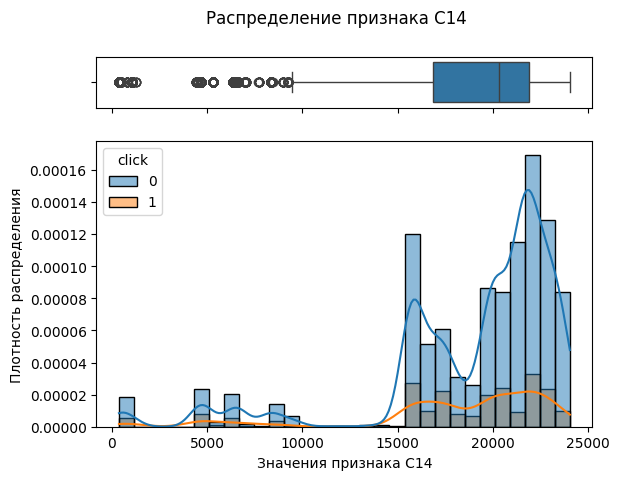

In [24]:
box_hist(df, 'C14', bins=30)



Есть выбросы в данных от 100 до 10000. Но из-за анонимизации как-то обработать выбросы осмысленным способом не получится. Оставляем как есть.

       ml_feature_9
count  49472.000000
mean       0.035519
std        0.504936
min       -2.147526
25%       -0.303903
50%        0.035905
75%        0.374325
max        2.120786


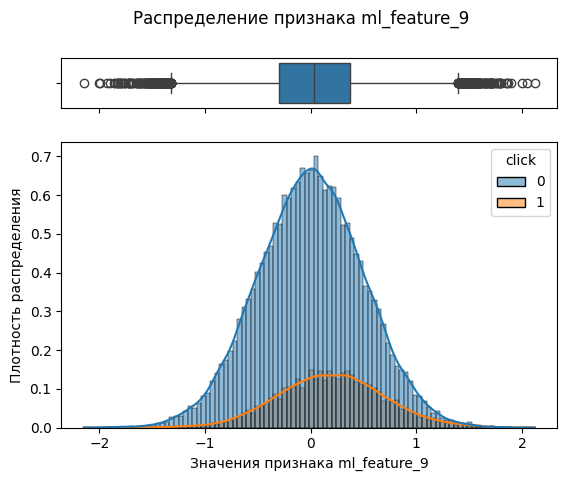

In [25]:
box_hist(df, 'ml_feature_9', bins=100)


Данный признак имеет колокообразное распределение с центром в нуле, причем объекты с кликом по по рекламе смещают распределение, так что центр проходит через 0.2. Выбросы обрабатывать не требуется.

       ml_feature_1
count  49472.000000
mean      -0.003093
std        1.000676
min       -4.631262
25%       -0.679151
50%       -0.004700
75%        0.673258
max        3.793828


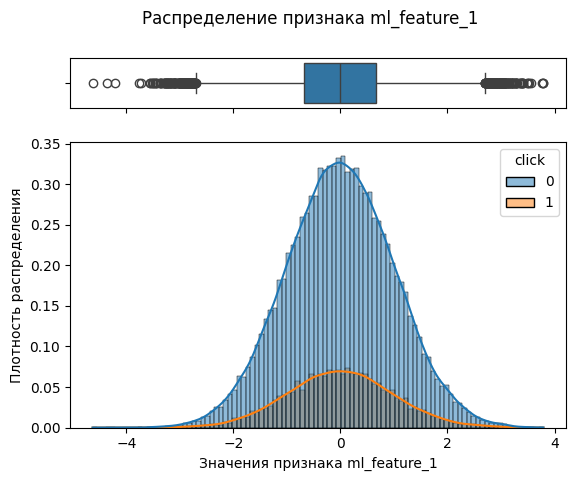

In [26]:
box_hist(df, 'ml_feature_1', bins=100)


Также не требуется обработка выбросов, распределение симметричное.

       ml_feature_3
count  49472.000000
mean      -0.037195
std        5.793686
min       -9.999742
25%       -5.062158
50%       -0.057679
75%        4.987824
max        9.999975


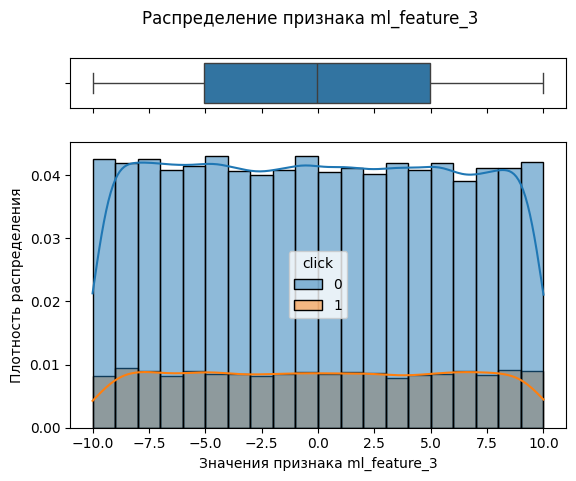

In [27]:
box_hist(df, 'ml_feature_3')


Признак распределен равномерно. Выбросы отсутствуют.

       ml_feature_5
count  49472.000000
mean       0.035498
std        1.002806
min       -4.631853
25%       -0.639086
50%        0.028812
75%        0.708553
max        4.230623


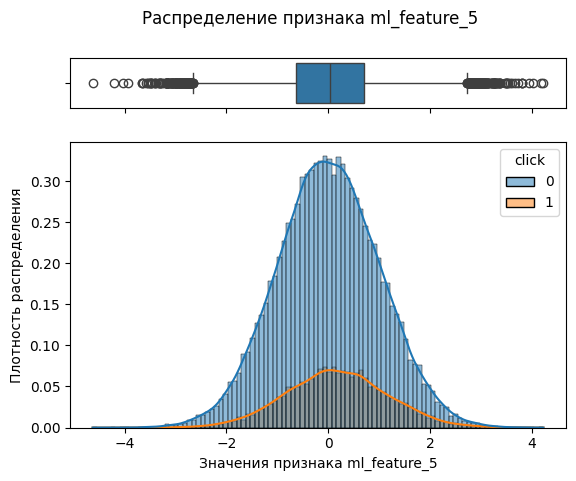

In [28]:
box_hist(df, 'ml_feature_5', bins=100)


Выбросы не требую обработки из-за формы распределения. Форма - симметричная

       ml_feature_6
count  49472.000000
mean       0.023107
std        0.656962
min       -1.000000
25%       -0.580564
50%        0.038110
75%        0.637967
max        1.000000


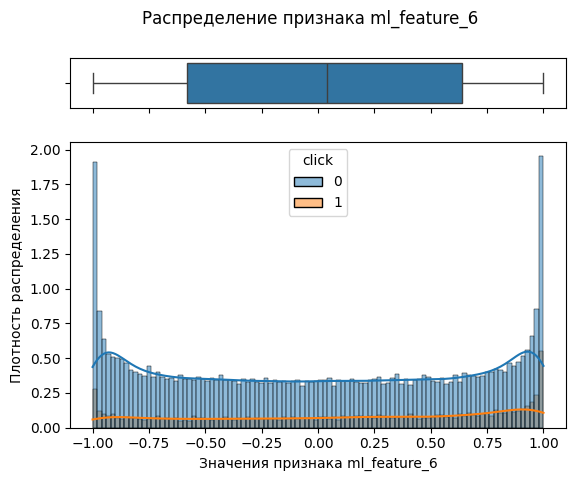

In [29]:
box_hist(df, 'ml_feature_6', bins=100)

Выбросов так же нет. Форма распределения близка к равномерному, но на концах распределения плотность повышенная.

       ml_feature_8
count  49472.000000
mean       0.025493
std        0.578141
min       -0.999965
25%       -0.470576
50%        0.027251
75%        0.521491
max        1.119858


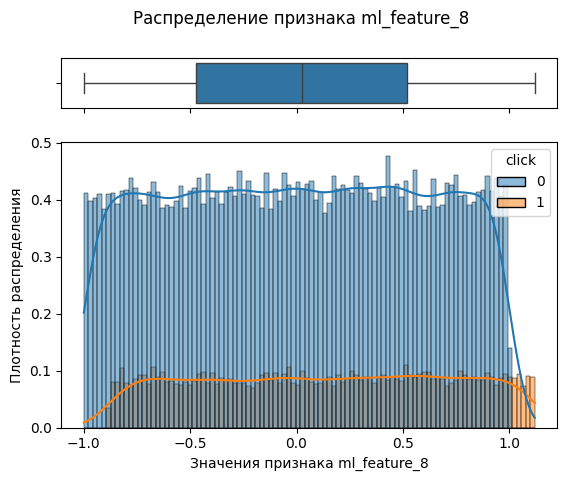

In [30]:

box_hist(df, 'ml_feature_8', bins=100)


У данного признака распределение близкое к равномерному, но видно смещение плотности распределения в зависимости от целевой переменной. Вероятно это полезный признак для модели.

Выглядит так, что данный признак содержит в себе data leakage - объекты положительного класса имеют явно отличающееся распределение значений: если значение этого признака больше 1 то можно с уверенностью сказать, что это положительный класс. Возможно здесь была допущена специальная ошибка составителями датасета.

       ml_feature_10
count   49472.000000
mean        0.020305
std         0.303305
min        -1.287965
25%        -0.182476
50%         0.019000
75%         0.224314
max         1.202300


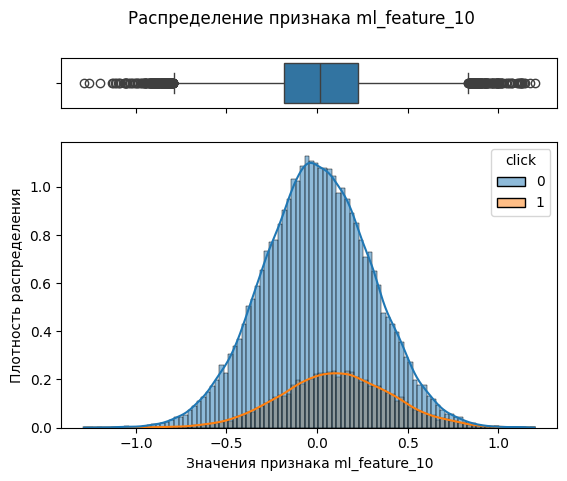

In [31]:
box_hist(df, 'ml_feature_10', bins=100)

Признак по своему распределению очень похож на ml_feature_9. Возможно это дублированных признаки. Проверим это:

In [32]:
(df['ml_feature_9'] - df['ml_feature_10']).sample(10, random_state=RANDOM_STATE)

16698    0.867443
23847   -0.305796
40063    0.192696
16936    0.491500
46269   -0.232438
1681     0.574374
18685   -0.255359
38244   -1.266370
34974   -0.900608
1334    -0.146305
dtype: float64

Это не дублированные признаки, так как разница значений по одинаковым индексам не нулевая. Возможно данные признаки коллинеарны.

#### 2.7 Корреляции
- Определите, какие признаки коррелируют с целевой переменной.
- Выявите сильно скоррелированные признаки, которые можно удалить, если такие есть.

Есть признаки, которые по смыслу очень скоррелированы друг с другом, например site_id и site_domain. Но сначала проанализируем их и удалим те из них, которые по сути дублируют информацию для модели, опираясь на анализ.

In [33]:
class CorrelationDisplayer:
    """
    Класс для отображения матрицы корреляций признаков в разных видах
    """
    def __init__(self, corr_matrix):
        self.df = df
        self.corr_matrix = corr_matrix

    def get_corr_matrix(self):
        return self.corr_matrix

    def _subset_corr_matrix(self, subset):
        subset_cols = self.corr_matrix.columns if subset is None else subset
        return self.corr_matrix.loc[subset_cols, subset_cols]

    def draw_corr_matrix_full(
            self,
            digits=2,
            title='Матрица корреляций признаков',
            subtitle=None,
            figsize=(16, 10),
            subset=None,
    ):
        plt.subplots(figsize=figsize)
        matrix = self._subset_corr_matrix(subset)
        sns.heatmap(matrix.round(digits), annot=True, cmap='coolwarm', linewidths=0.5)
        plt.title(title + "\n" + subtitle if subtitle else title)
        plt.show()


    def draw_corr_matrix_with_target(
            self,
            target_col,
            title='Матрица корреляций с таргетом',
            subtitle=None,
            figsize=(16, 10),
    ):
        plt.subplots(figsize=figsize)
        data_heatmap = self.corr_matrix.loc[
            self.corr_matrix.index != target_col
        ][[target_col]].sort_values(by=target_col, ascending=False)
        sns.heatmap(data_heatmap, annot=True, cmap='coolwarm', linewidths=0.5)
        plt.title(title + "\n" + subtitle if subtitle else title)
        plt.show()

    def draw_pair_correlations(self, subset=None, figsize=(16, 10), corr_threshold=0.9):
        # преобразуем матрицу корреляции в датафрейм попарных корреляций
        # feature_1+feature_2 -> correlation
        matrix = self._subset_corr_matrix(subset)
        pair_correlations = matrix \
            .stack() \
            .reset_index() \
            .rename(columns={
                'level_0': 'feature1',
                'level_1': 'feature2',
                0: 'correlation'
            }) \
            .query('feature1 != feature2') \
            .sort_values(by='correlation', ascending=False) \

        def order_pair(row):
            if row['feature1'] > row['feature2']:
                return row['feature2'] + '/' + row['feature1']
            else:
                return row['feature1'] + '/' + row['feature2']

        pair_correlations['order_pair'] = pair_correlations.apply(order_pair, axis=1)
        pair_correlations = pair_correlations.drop(columns=['feature1', 'feature2'])
        pair_correlations = pair_correlations.drop_duplicates().reset_index(drop=True)
        pair_correlations = pair_correlations.query('correlation > @corr_threshold')
        pair_correlations = pair_correlations.sort_values(by='correlation')
        pair_correlations.plot(
            x='order_pair',
            y='correlation',
            xlabel='Значение корреляции',
            ylabel='Пара признаков',
            kind='barh',
            legend=False,
            figsize=figsize,
            grid=True,
        )
        plt.title('Попарные корреляции')
        plt.show()
        return pair_correlations.sort_values(by='correlation', ascending=False).reset_index(drop=True)


Построим матрицу корреляций:

In [34]:
full_corr_matrix = df.phik_matrix(interval_cols=[
    'C1',
    'C14',
    'C17',
    'C19',
    'C20',
    'C21',
    'ml_feature_1',
    'ml_feature_3',
    'ml_feature_5',
    'ml_feature_6',
    'ml_feature_8',
    'ml_feature_9',
    'ml_feature_10',
])



/Users/ngsmirnov/nikki/projects/practicum/sprint12_svm_prob_calib_ftr_slctn/.venv/lib/python3.12/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable device_model is large: 2478. Are you sure this is not an interval variable? Analysis for pairs of variables including device_model can be slow.
  warnings.warn(
/Users/ngsmirnov/nikki/projects/practicum/sprint12_svm_prob_calib_ftr_slctn/.venv/lib/python3.12/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable site_domain is large: 1004. Are you sure this is not an interval variable? Analysis for pairs of variables including site_domain can be slow.
  warnings.warn(
/Users/ngsmirnov/nikki/projects/practicum/sprint12_svm_prob_calib_ftr_slctn/.venv/lib/python3.12/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable site_id is large: 1142. Are you sure this is not an interval variable? Analysis for pairs of variables including 

Выведем тепловую карту корреляций признаков с таргетом:

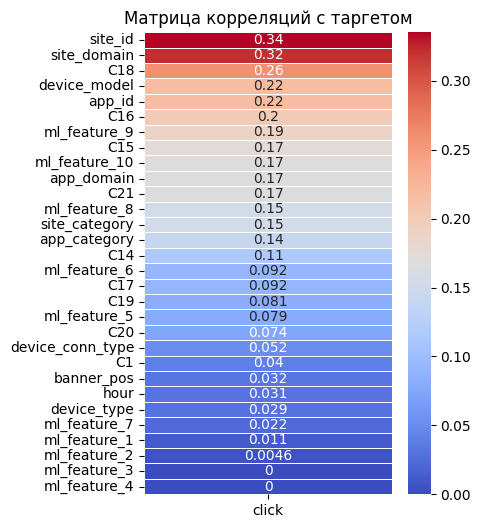

In [35]:
corr_displayer = CorrelationDisplayer(
    full_corr_matrix
)
corr_displayer.draw_corr_matrix_with_target(TARGET, figsize=(4, 6))


Умеренная корреляция наблюдается у признаков
- site_id,
- site_domain
- C18
- app_id
- device_model
- ml_feature_9/10
- C21/15
- app_domain/app_category
- site_category

Остальные признаки имеют от слабой до незначительной корреляции с целевой переменной.

Признаки ml_feature_3 и ml_feature_4 имеют нулевую корреляцию с целевой переменной.

Оценим корреляцию всех признаков друг с другом. Для этого выведем полную тепловую карту корреляционной матрицы:

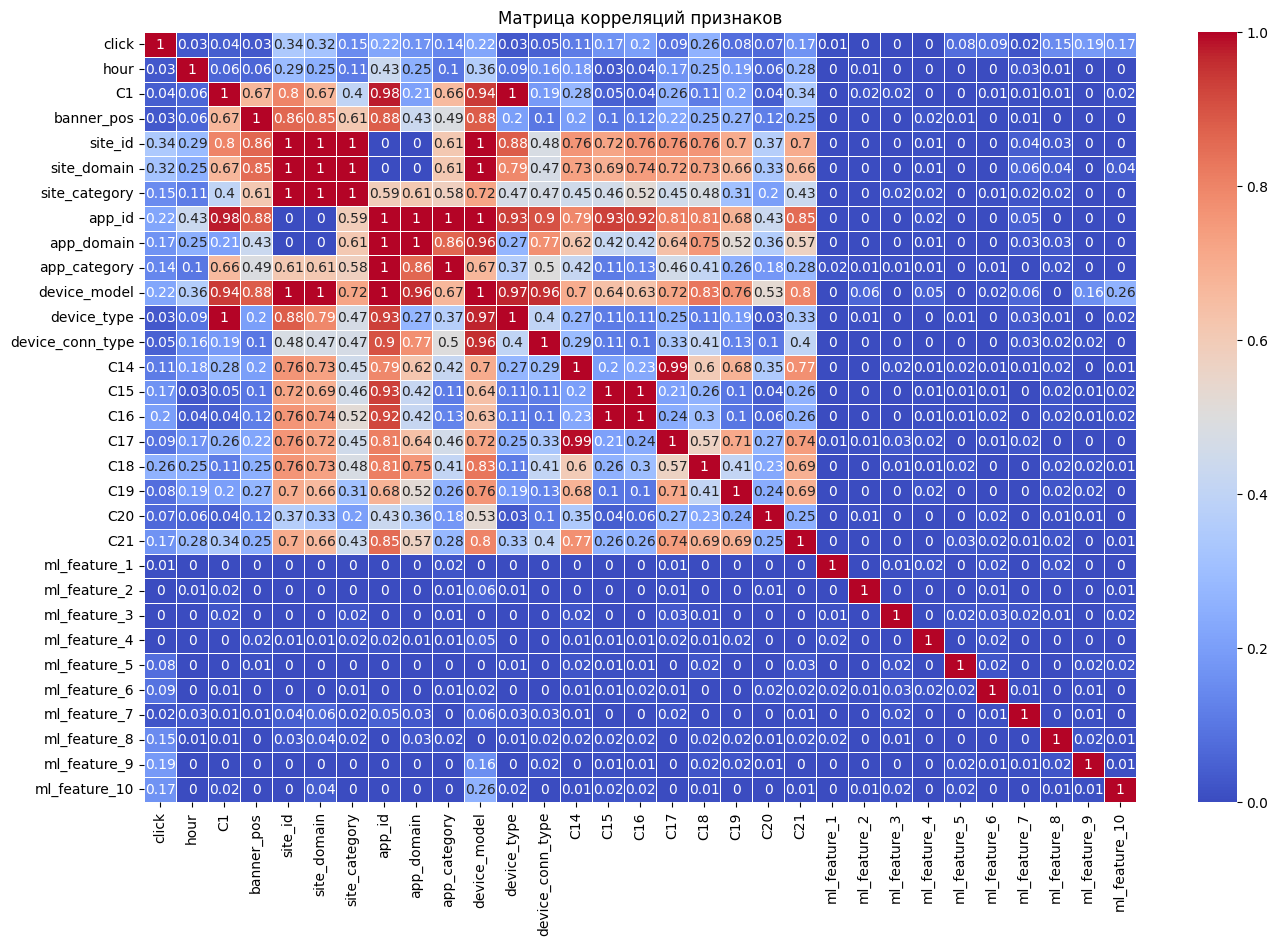

In [36]:
corr_displayer.draw_corr_matrix_full()



По тепловой карте, построенной на основе корреляционной матрицы видно, что она бьется на 2 группы признаков:
- ml_feature*
- остальные

Причем первая группа практически не скоррелирована с остальными, поэтому далее будем анализировать эти группы по отдельности для удобства:

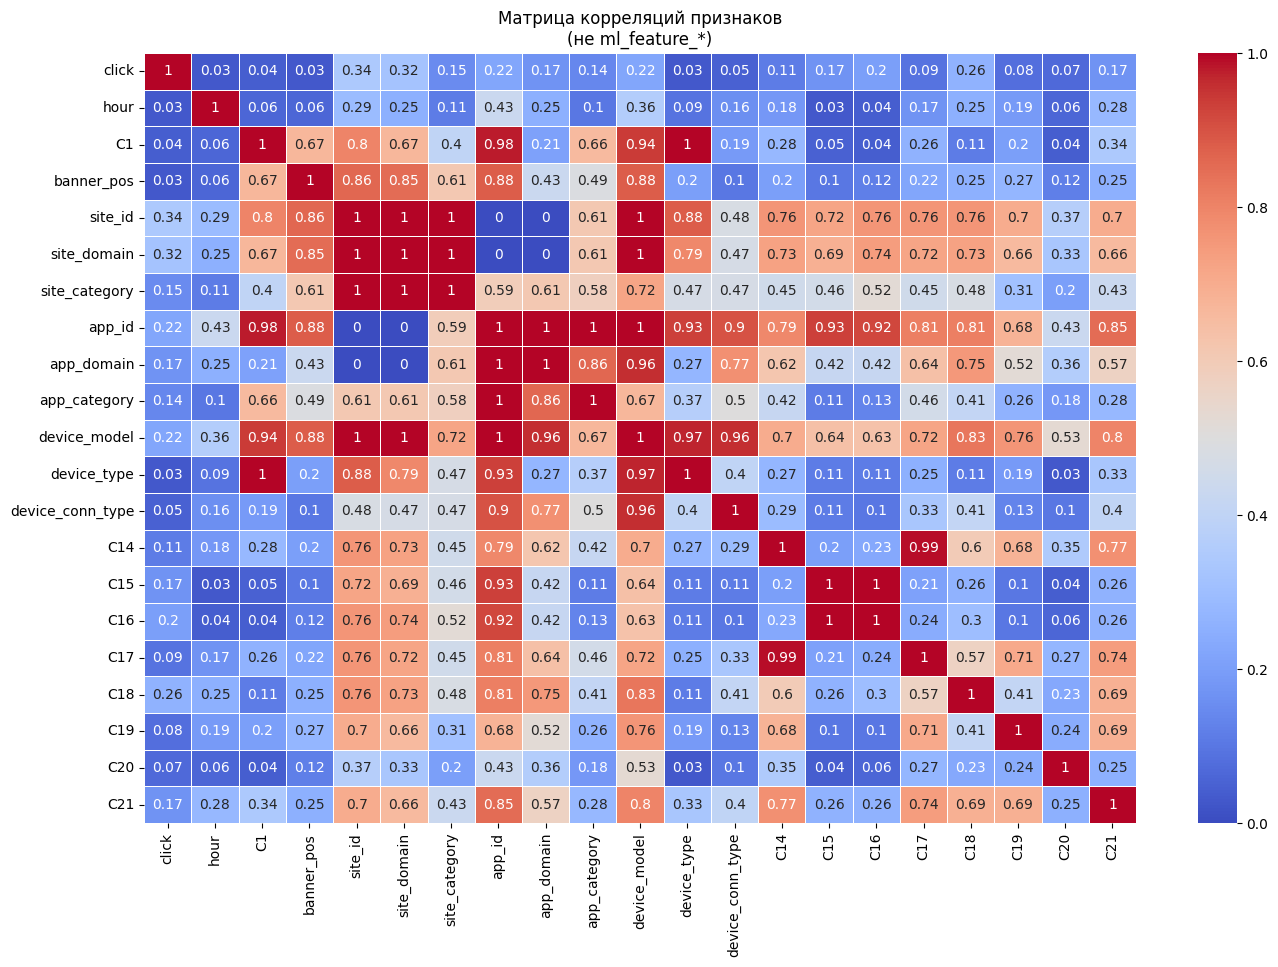

In [37]:

non_ml_feature_cols = [x for x in df.columns if 'ml_feature_' not in x]

corr_displayer.draw_corr_matrix_full(
    subtitle='(не ml_feature_*)',
    subset=non_ml_feature_cols,
)


Для удобства сформируем таблицу пар признаков с наибольшей корреляцией, убрав дублирование, присутствующее в матрице.

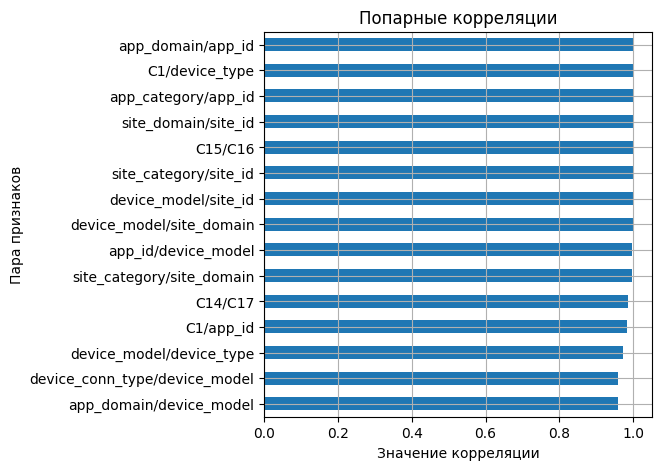

,correlation,order_pair
0,1.000000,app_category/app_id
1,1.000000,C1/device_type
2,1.000000,app_domain/app_id
3,0.999995,site_domain/site_id
4,0.999759,C15/C16
5,0.999732,site_category/site_id
6,0.998968,device_model/site_id
7,0.998922,device_model/site_domain
8,0.997081,app_id/device_model
9,0.996416,site_category/site_domain


In [38]:
corr_displayer.draw_pair_correlations(corr_threshold=0.95, figsize=(5, 5))



По полученой матрице и таблице пар признаков с наибольшей корреляцией можно сделать вывод:

Абсолютная корреляция присутствует между признаками:
- device_model/site_domain
- device_model/site_id
- device_model/app_id
- app_domain/app_id
- app_category/app_id
- site_domain/site_id
- site_category/site_id
- site_category/site_domain
- C15/C16


Данная связь довольно очевидна site_id/site_domain/site_category, но пока неясно, какой признак лучше всего оставить.
Если взять только site_category, отбросив другие два признака, есть шанс, что он будет обладать наилучшей обобщающей способностью, так как категория сайта - это довольно общее понятие, но этот признак имеет наименьшую из трех корреляцию с целевой переменной. Поэтому пока оставим site_category и site_domain, отбросив site_id.

То же замечание касается признаков app_id, app_category и app_domain: отбросим app_id, тем более, что app_category/app_domain скоррелированы на 0.86
Признак device_model абсолютно скоррелирован с site_id и site_domain и с app_id, что не поддается логическому объяснению, поэтому оставим эти признаки до этапа отбора через оберточные методы.

Наблюдаются абсолютные корреляции C15 и C16. Оставим C16 - у него больше корреляция с целевой переменной.

- высокие корреляции (0.99) C14 и C17 (оставим C14 - у него больше корреляция с целевой переменной)
- app_id сильно (0.98) коррелирует с C1, но мы уже решили убрать app_id, С1 остается
- device_type абсолютно скоррелирован с C1 и сильно (0.94) с device_model - оставим device_model, удалим device_type
- device_type сильно (0.97) коррелирует с device_model. оставим до отбора через оберточные методы
- device_conn_type сильно (0.96) коррелирует с device_model, оставим до отбора через оберточные методы

Итого можно удалить следующие признаки:

- site_id,
- app_id,
- C15,
- C17,
- device_type,

In [39]:
df.drop(columns=[
    'site_id',
    'app_id',
    'C15',
    'C17',
    'device_type',
], inplace=True)

Теперь рассмотрим вторую группу признаков ml_feature_* в корреляционной матрице.

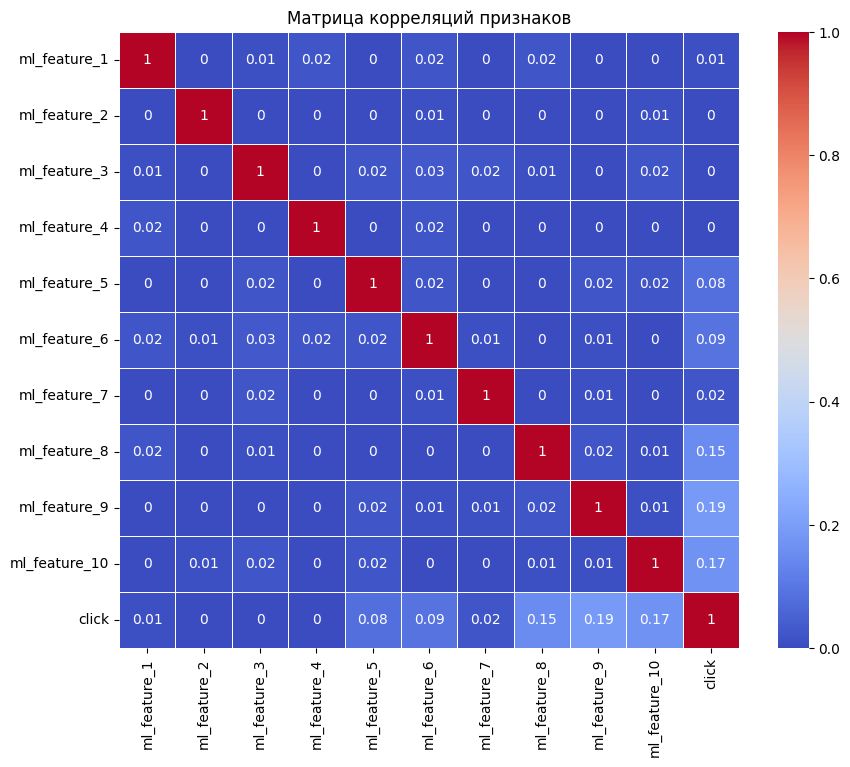

In [40]:

ml_feature_cols = [x for x in df.columns if 'ml_feature_' in x]
ml_feature_cols.append(TARGET)
corr_displayer.draw_corr_matrix_full(subset=ml_feature_cols, figsize=(10, 8))


В данной матрице нет даже средне скоррелированных признаков, поэтому все их оставляем в датасете до этапа обучения модели. Отметим так же, что приведенные признаки слабо скоррелированны с целевой переменной. Самые перспективные признаки - ml_feature_9, ml_feature_10, ml_feature_8. 


#### 2.8 Выводы по EDA
- Кратко опишите ключевые находки.
- Выберите признаки, которые выглядят наиболее перспективными для модели. Выбор обоснуйте.
- Определите действия по предобработке данных, которые необходимо проделать.

Проанализированный датасет соответствует предоставленному описанию. Он содержит данные за 10 дней с рекламными событиями. Целевая переменная click представлена в виде значений 0 и 1, где 1 означает клик на рекламное объявление. В данных наблюдается значительный дисбаланс классов: положительный класс составляет 17% от всех наблюдений.

Для улучшения качества данных были произведены некоторые преобразования:
- из данных в столбце hour была отброшена дата и оставлена информация о часе
- id, device_id, device_ip были удалены как незначемые признаки для обучения, они представляют из себя техническую информацию
- подсчитано, что в датасете фигурирует информация о 1013 доменах рекламных площадок из 18 категорий и рекламируется 967 приложений из 22 категорий

Пропусков в датасете не обнаружено.

Среди категориальных признаков присутствует небольшое число категорий в которых драматически мало объектов. Такие мало представленные категории были удалены, при этом датасет сократился на 1% строк.

Проведенный анализ выбросов в числовых признаках выявил, что специально обработки они не требуют. Однако необходимо будет масштабирование.

Корреляционный анализ выявил несколько признаков, которые имеют абсолютную корреляцию между собой. Избыточные признаки были удалены: site_id, app_id, C15, C17, device_type. Другие признаки, корреляция между которыми меньше 0.98 были оставлены для отбора призаков встроенными методами и методами обертками.

<a id="train-test-split"></a>
## 3. Разделение данных на выборки

Разделим отделим от датасета целевую переменную и признаки а также сделаем выборки для обучения/валидации и для теста

In [41]:

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train_val, X_test, y_train_val, y_test = train_test_split(
      X, y,
      shuffle=True,
      stratify=y,
      test_size=0.2,
      random_state=RANDOM_STATE,
)
print(f'Размер выборки для обучения: '
      f'X_train_val={X_train_val.shape}, y_train_val={y_train_val.shape}')

print(f'Размер выборки для теста: '
      f'X_test={X_test.shape}, y_test={y_test.shape}')



Размер выборки для обучения: X_train_val=(39577, 25), y_train_val=(39577,)
Размер выборки для теста: X_test=(9895, 25), y_test=(9895,)


Выборки разделены в пропорции 80 - на обучение, 20 - на тестирование.

Проверим пропорции целевого класса в выборках:

In [42]:
print(f'Доля y=1 в train_val: {y_train_val.mean()}')
print(f'Доля y=1 в test: {y_test.mean()}')

Доля y=1 в train_val: 0.17254971321727267
Доля y=1 в test: 0.17261243052046488


Пропоции положительного класса одинаковы в трейне и тесте.

<a id="preprocessing"></a>
## 4. Предобработка данных — построение пайплайнов

#### 4.1 Создайте пайплайн для предобработки данных

**Для числовых признаков:**
- Корректно заполните пропуски — средним, медианой или другим методом.
- Масштабируйте данные с помощью `StandardScaler`.
- Обработайте выбросы, если необходимо.

**Для категориальных признаков:**
- Корректно заполните пропуски — значением по умолчанию или модой.
- Примените кодирование:
  - One-Hot Encoding для признаков с малой кардинальностью.
  - Target Encoding для признаков с высокой кардинальностью.

#### 4.2 Объедините пайплайны
- Используйте `sklearn.pipeline.Pipeline` и `ColumnTransformer`.
- **Важно:** используйте информацию о пропусках и категориях только из обучающей выборки!

Распределим фичи по группам в зависимости от способа обработки:

In [43]:

TARGET_ENCODED_FEATURES = [
    'site_domain',       # str
    'site_category',     # str
    'app_domain',        # str
    'app_category',      # str
    'device_model',      # str
]
OHE_FEATURES = [
    'ml_feature_2',      # str
    'ml_feature_7',      # str
]
NUM_FEATURES = [
    'hour',              # int64
    'C1',                # int64
    'banner_pos',        # int64
    'C14',               # int64
    'C16',               # int64
    'C18',               # int64
    'C19',               # int64
    'C20',               # int64
    'C21',               # int64
    'ml_feature_1',      # float64
    'ml_feature_3',      # float64
    'ml_feature_4',      # int64
    'ml_feature_5',      # float64
    'ml_feature_6',      # float64
    'ml_feature_8',      # float64
    'ml_feature_9',      # float64
    'ml_feature_10',     # float64
]


Определим пайплайны предобработки признаков.

In [44]:
cat_ohe_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first')),
])

cat_target_encoded_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_encoder', TargetEncoder(
        target_type='binary',
        smooth='auto',
        shuffle=True,
        cv=5, # для предотвращения Data Leakage
        random_state=RANDOM_STATE,
    )),
])

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

preprocessor = ColumnTransformer(
    [
        ('num', num_pipeline, NUM_FEATURES),
        ('cat_ohe', cat_ohe_pipeline, OHE_FEATURES),
        ('cat_taret_encoded', cat_target_encoded_pipeline, TARGET_ENCODED_FEATURES),
    ],
    remainder='drop',
)

preprocessor_with_scaler = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
])

def define_lr(
    class_weight=None,
    penalty='l2',
    solver='liblinear',
    tol=1e-4,
    max_iter=1000,
    C=1,
):
    return LogisticRegression(
        random_state=RANDOM_STATE,
        penalty=penalty,
        solver=solver,
        tol=tol,
        max_iter=max_iter,
        C=C,
        class_weight=class_weight,
    )

def define_svc(
        probability=True,
        max_iter=4000,
        C=0.5,
        kernel='linear',
        class_weight='balanced',
):
    return SVC(
        random_state=RANDOM_STATE,
        probability=probability,
        max_iter=max_iter,
        C=C,
        kernel=kernel,
        class_weight=class_weight,
    )

# финальный пайплайн с стардартизацией признаков после one-hot/target encoding
def build_final_pipeline(model):
    return Pipeline([
        ('preprocessor', preprocessor_with_scaler),
        ('model', model),
    ])

pipeline_lr = build_final_pipeline(define_lr())
pipeline_svm = build_final_pipeline(define_svc())
pipeline_dummy = build_final_pipeline(DummyClassifier(strategy='stratified'))

<a id="feature-selection"></a>
## 5. Отбор признаков


#### 5.1 Применим фильтрационные методы
- Посчитайте корреляцию каждого признака с целевой переменной.
- Отберите топ лучших признаков. Объясните, почему остановились именно на таком количестве признаков.
- Удалите признаки с очень низкой вариацией `VarianceThreshold`.


Еще раз посмотрим на корреляции признаков с целевой переменной.

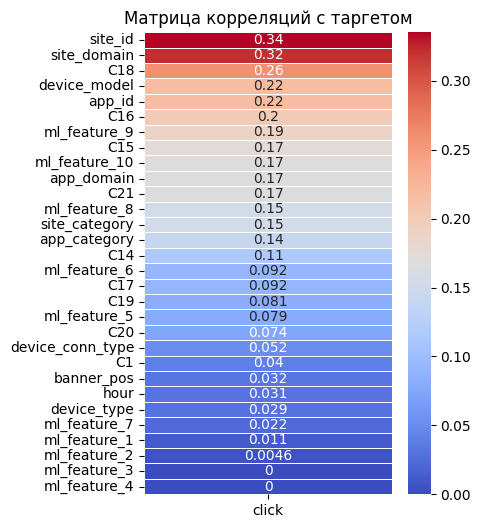

In [45]:
corr_displayer.draw_corr_matrix_with_target(TARGET, figsize=(4, 6))

Признаки ml_feature_3 b и ml_feature_4 имеют нулевую корреляцию с целевой переменной, но возможно они оказывают влияние совместно с другими признаками, поэтому на данном этапе не будем отбрасывать их. 

Проверим вариативность признаков c помощью VarianceThreshold

In [46]:
# Отбираем числовые признаки
numerical_columns = df.select_dtypes(include=[np.number]).columns
numerical_data = df[numerical_columns]

# Обучаем VarianceThreshold
vs_constant = VarianceThreshold(threshold=0.1)
# 0.1 для квази-константных признаков (которые у большинства объектов)
vs_constant.fit(numerical_data)

# Находим константные числовые признаки
constant_num_columns = [col for col, keep in zip(numerical_columns, vs_constant.get_support()) if not keep]
constant_num_columns

['ml_feature_10']

Единственный признак с малой вариативностью (дисперсия меньше 0.1) - ml_feature_10.
Дополнительно исследуем этот признак для того, чтобы решить, стоит ли его удалять.

In [47]:
# Проверяем дисперсию признака
variance = df['ml_feature_10'].var()
print(f"Дисперсия ml_feature_10: {variance}")

Дисперсия ml_feature_10: 0.0919941003150878


Дисперсия, как и ожидалось, меньше 0.1. Посмотрим на другие статистики данного признака:

In [48]:
# Проверяем основные статистики
print(df['ml_feature_10'].describe())

# Проверяем количество уникальных значений
print(f"Уникальных значений: {df['ml_feature_10'].nunique()}")

count    49472.000000
mean         0.020305
std          0.303305
min         -1.287965
25%         -0.182476
50%          0.019000
75%          0.224314
max          1.202300
Name: ml_feature_10, dtype: float64
Уникальных значений: 49472


Данный признак не похож на квази-константный. Он имеет большое количество уникальных значений и как мы видили на этапе EDA, распределен колокообразно. Дисперсия невелика из-за того, что значения признака близко к стандартизированному.

Кроме того, признак имеет слабую корреляцию с целевой переменной (0.17) и по этой причине может быть полезен при обучении модели.

Итого: оставляем данный признак

#### Отбор признаков по критерию взаимной информации

Вычислим метрику взаимной информации (mutual information или MI) всех признаков с целевой переменной:

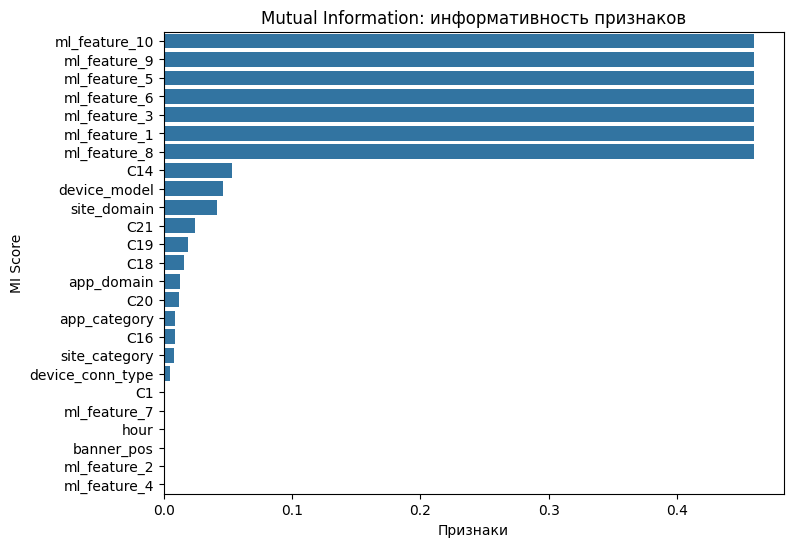

In [49]:

mi_scores = mutual_info_classif(X_train_val, y_train_val, discrete_features=True)
mi_scores = pd.Series(mi_scores, index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)

# визуализация
plt.figure(figsize=(8, 6))
sns.barplot(
    y=mi_scores.index,
    x=mi_scores.values,
    orient='h'
)
plt.title("Mutual Information: информативность признаков")
plt.ylabel("MI Score")
plt.xlabel("Признаки")
plt.show()

Как видно из представленной диаграммы, почти всепризнаки вносят некоторый вклад в целевую переменную, за исключением C1, ml_reature_7, hour, banner_pos, ml_feature_2, ml_feature_4. Это повод отбросить перечисленные признаки. Однако MI-анализ является дополнительной информацией, которую можно использовать для выбора признаков, поэтому окончательное решение о необходимости удаления перечисленных признаков будет принято на этапе применения оберточных методов отбора. 

Интересная особенность: ml_feature_3 и ml_feature_1 по вышеприведенному анализу имеют наименьшие корреляции с таргетом, тогда как в MI-оценке они сопоставимы с ml_feature_10 и ml_feature_9 (большие скоры как в MI так и в корреляционном анализе). Следовательно их не следует отбрасывать.


#### 5.2 Примените методы-обёртки



Применим методы-обертки, чтобы выяснить, какие признаки оказываются полезнее всего для модели в контексте улучшения целевой метрики - PR-AUC.

In [50]:
scoring_metric = 'average_precision'

# Предварительный fit() для получения имён преобразованных признаков (после кодирования)
X_processed = preprocessor.fit_transform(X_train_val, y_train_val)
feature_names = preprocessor.get_feature_names_out()

estimator = define_lr()

# Выбор признаков с помощью SequentialFeatureSelector
sfs = SequentialFeatureSelector(
    estimator,
    n_features_to_select='auto',
    direction='forward',
    cv=5,
    scoring=scoring_metric,
    n_jobs=-1,
    tol=0.00001,
)
# отбор признаков ведем на преобразованном
sfs.fit(X_processed, y_train_val)

SequentialFeatureSelector(estimator=LogisticRegression(C=1, max_iter=1000,
                                                       random_state=153,
                                                       solver='liblinear'),
                          n_jobs=-1, scoring='average_precision', tol=1e-05)

Выведем отобранные фичи:

In [51]:
selected_features_idx = sfs.get_support()
selected_features = pd.DataFrame(feature_names).loc[selected_features_idx].reset_index(drop=True).rename(columns={0: 'feature'})
print('Оригинальный размер множества признаков:', len(feature_names))
print('Размер множества признаков после фильтрации:', len(selected_features))
selected_features


Оригинальный размер множества признаков: 28
Размер множества признаков после фильтрации: 19


,feature
0,num__hour
1,num__C1
2,num__C14
3,num__C16
4,num__C19
5,num__C21
6,num__ml_feature_5
7,num__ml_feature_6
8,num__ml_feature_8
9,num__ml_feature_9


Проверим качество на отложенной выборке:

In [52]:
X_train_val_ffs = sfs.transform(X_processed)
X_test_processed = preprocessor.fit_transform(X_test, y_test)
X_test_ffs = sfs.transform(X_test_processed)

estimator.fit(X_train_val_ffs, y_train_val)
y_pred_ffs = estimator.predict(X_test_ffs)
y_pred_proba_ffs = estimator.predict_proba(X_test_ffs)[:, 1]
print('Метрики модели с отбором признаков:')
print(
    f'pr-auc:    {average_precision_score(y_test, y_pred_proba_ffs):.4f}',
    f'precision: {precision_score(y_test, y_pred_ffs):.4f}',
    f'recall:    {recall_score(y_test, y_pred_ffs):.4f}',
    f'f1:        {f1_score(y_test, y_pred_ffs):.4f}',
    sep='\n',
)

Метрики модели с отбором признаков:
pr-auc:    0.3838
precision: 0.5981
recall:    0.1107
f1:        0.1868


Ну, что ж, качество не сказать что очень хорошее.

Метрики модели с отбором признаков:
- pr-auc:    0.3838
- precision: 0.5981
- recall:    0.1107
- f1:        0.1868

Но этот метод позволил нам отобрать признаки, действительно важные для ключевой метрики:

- device_model
- app_category
- app_domain
- site_category
- site_domain
- ml_feature_7
- ml_feature_2
- ml_feature_10
- ml_feature_9
- ml_feature_8
- ml_feature_6
- ml_feature_5
- C21
- C19
- C16
- C14
- C1
- hour

Отобразим веса признаков на графике:

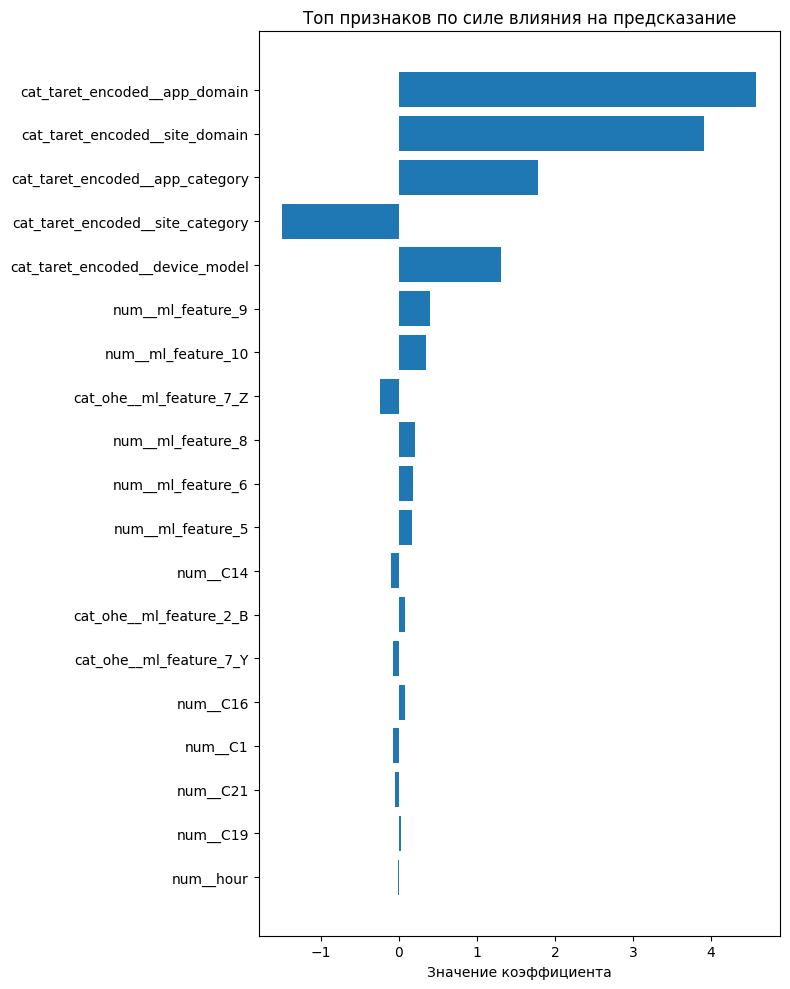

,feature,coefficient,abs_coefficient
0,cat_taret_encoded__app_domain,4.583181,4.583181
1,cat_taret_encoded__site_domain,3.913879,3.913879
2,cat_taret_encoded__app_category,1.779977,1.779977
3,cat_taret_encoded__site_category,-1.496566,1.496566
4,cat_taret_encoded__device_model,1.309164,1.309164
5,num__ml_feature_9,0.403270,0.403270
6,num__ml_feature_10,0.345013,0.345013
7,cat_ohe__ml_feature_7_Z,-0.246777,0.246777
8,num__ml_feature_8,0.206725,0.206725
9,num__ml_feature_6,0.184011,0.184011


In [53]:
def feature_importance(model, feature_names):
    # Получаем коэффициенты
    coefficients = model.coef_[0]
    intercept = model.intercept_[0]

    # DataFrame для анализа для удобства анализа коэффициентов
    coef_df = pd.DataFrame({
        'feature': feature_names,
        'coefficient': coefficients,
        'abs_coefficient': np.abs(coefficients)
    }).sort_values('abs_coefficient', ascending=False)

    # Визуализируем важность признаков:
    plt.figure(figsize=(8, 10))
    top_features = coef_df.sort_values(by='abs_coefficient', ascending=True)
    plt.barh(range(len(top_features)), top_features['coefficient'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Значение коэффициента')
    plt.title('Топ признаков по силе влияния на предсказание')
    plt.tight_layout()
    plt.show()

    return {
        'weights': coef_df.reset_index(drop=True),
        'intercept': intercept
    }

feature_importance(estimator, feature_names[sfs.get_support()])['weights']


#### 5.3 Выберите финальный набор признаков


Подводя итоги корреляционного анализа и оценки взаимной информации признаков с целевой переменной, финальный набор признаков на данном этапе будет иметь вид

- device_model
- app_category
- app_domain
- site_category
- site_domain
- ml_feature_7
- ml_feature_2
- ml_feature_10
- ml_feature_9
- ml_feature_8
- ml_feature_6
- ml_feature_5
- C21
- C19
- C16
- C14
- C1
- hour

<a id="baseline"></a>

## 6. Обучение базовой модели

### 6.1 Обучите `DummyClassifier`
- Это нужно, чтобы обозначить самый простой базовый уровень работы модели.

### 6.2 Обучите `LogisticRegression`
- Используйте для обучения отобранные признаки.
- Примените кросс-валидацию на 5 фолдах.
- Посчитайте метрику PR-AUC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Напоминаем, что для корректной кросс-валидации, предобработку нужно объединить с классификатором в Pipeline.

### 6.3 Обучите `SVC`

- Обучите SVC линейным ядром.
- Примените кросс-валидацию на 5 фолдах и посчитайте ту же метрику PR-ROC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Калибровку модели мы проведём далее, поэтому здесь нужна модель `probability=False`

### 6.4 Сравните модели
- Убедитесь, что `LogisticRegression` работает лучше `DummyClassifier`.
- Сравните качество `LogisticRegression` с `SVC`.

Определим целевые метрики:

In [54]:
scoring = [
    'average_precision',
    # 'neg_log_loss',
    # 'neg_brier_score',
    'precision',
    'recall',
    'f1'
]

TARGET_ENCODED_FEATURES_SELECTED = [
    'site_domain',       # str
    'site_category',     # str
    'app_domain',        # str
    'app_category',      # str
    'device_model',      # str
]
OHE_FEATURES_SELECTED = [
    'ml_feature_2',      # str
    'ml_feature_7',      # str
]

NUM_FEATURES_SELECTED = [
    'ml_feature_10',
    'ml_feature_9',
    'ml_feature_8',
    'ml_feature_6',
    'ml_feature_5',
    'C21',
    'C19',
    'C16',
    'C14',
    'C1',
    'hour',
]


Определим пайплайн для обучения моделей и переопределим препроцессор (так как состав признаков был изменен после отбора): базовые модели LogisticRegression и SVM, а также DummyClassifier для проверки модели на адекватность.

In [55]:
preprocessor = ColumnTransformer(
    [
        ('cat_ohe', cat_ohe_pipeline, OHE_FEATURES_SELECTED),
        ('cat_taret_encoded', cat_target_encoded_pipeline, TARGET_ENCODED_FEATURES_SELECTED),
        ('num', num_pipeline, NUM_FEATURES_SELECTED),
    ],
    remainder='drop',
)

pipeline_lr = build_final_pipeline(define_lr())
pipeline_svm = build_final_pipeline(define_svc())
pipeline_dummy = build_final_pipeline(DummyClassifier(strategy='stratified'))

pipelines = {
    'Logistic Regression': pipeline_lr,
    'SVM': pipeline_svm,
    'Dummy Classifier': pipeline_dummy,
}

Обучим пайплайны на кросс валидации сохраним результаты обучения в словарь по имени модели:

In [56]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

cv_results_by_model = {}

for model_name, pipeline in pipelines.items():
    cv_results = cross_validate(
        estimator=pipeline,
        X=X_train_val,
        y=y_train_val,
        cv=skf,
        scoring=scoring,
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
    )

    cv_results_by_model[model_name] = cv_results



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
/Users/ngsmirnov/nikki/projects/practicum/sprint12_svm_prob_calib_ftr_slctn/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=4000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/ngsmirnov/nikki/projects/practicum/sprint12_svm_prob_calib_ftr_slctn/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=4000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/ngsmirnov/nikki/projects/practicum/sprint12_svm_prob_calib_ftr_slctn/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=4000).  Co

Сформируем сравнительную таблицу результатов с метриками обученных моделей:

In [57]:
def append_metrics(result_metrics, model_name, cv_results, test_or_train='test', scoring=[]):
    metrics_dict = {
        metric: np.mean(cv_results[f'{test_or_train}_{metric}']) for metric in scoring
    }
    metrics_dict['model_name'] = model_name
    result_metrics.append(metrics_dict)
    return metrics_dict

metrics_df_list = []
for model_name, model_cv_results in cv_results_by_model.items():
    append_metrics(
        metrics_df_list,
        model_name,
        model_cv_results,
        scoring=scoring,
    )
    if 'dummy' not in model_name.lower():
        append_metrics(
            metrics_df_list,
            f'{model_name} (train)',
            model_cv_results,
            test_or_train='train',
            scoring=scoring,
        )

metrics_df = pd.DataFrame(metrics_df_list)
metrics_df.set_index('model_name').round(3)

,average_precision,precision,recall,f1
model_name,,,,
Logistic Regression,0.393,0.601,0.113,0.190
Logistic Regression (train),0.465,0.699,0.145,0.240
SVM,0.227,0.200,0.680,0.309
SVM (train),0.224,0.198,0.674,0.305
Dummy Classifier,0.174,0.174,0.171,0.172


Вывод: первый наивный подход дает качество модели, недостаточное для производственной эксплуатации. Модели логистической регрессии всего лишь в 1.5-3 раза превосходят наивный классификатор DummyClassifier по метрике PR-AUC. Полнота и точность так же находятся на низком уровне - около 60% точность, и полнота 5-10 процентов. Для эффективной конкуренции на рекламном рынке этого явно недостаточно.

Если сравнивать SVM и LogisticRegression, то можно cказать следующее:
- метод опорных векторов проигрывает по целевой метрике в 2 раза
- SVM в 6 раз лучше по полноте
- Точность у SVM в 3 раза хуже

Также видно, что модели имеют склонность к переобучению, так как метрики на обучающей выборке превышают метрики на отложенной выборке.

Сохраним бейзлайновые метрики в переменные для последующего сравнения на тестовой выборке. Для этого обучим бейзлайны на полной выборке трейн+вал и подсчитаем метрики на тесте.

In [58]:
def predict_and_score(model_name, estimator, X_test, y_test, digits=4):
    y_pred = estimator.predict(X_test)
    y_pred_proba = estimator.predict_proba(X_test)[:, 1]
    return {
        'model_name': model_name,
        'pr_auc': round(average_precision_score(y_test, y_pred_proba), digits),
        'precision': round(precision_score(y_test, y_pred), digits),
        'recall': round(recall_score(y_test, y_pred), digits),
        'f1': round(f1_score(y_test, y_pred), digits),
    }

pipelines['Logistic Regression'].fit(X_train_val, y_train_val)
lr_scores = predict_and_score('Logistic Regression', pipelines['Logistic Regression'], X_test, y_test)
pd.DataFrame(lr_scores, index=['model_name'])

,model_name,pr_auc,precision,recall,f1
model_name,Logistic Regression,0.3839,0.5833,0.1107,0.186


In [59]:
pipelines['SVM'].fit(X_train_val, y_train_val)
svm_scores = predict_and_score('SVM', pipelines['SVM'], X_test, y_test)
pd.DataFrame(svm_scores, index=['model_name'])

/Users/ngsmirnov/nikki/projects/practicum/sprint12_svm_prob_calib_ftr_slctn/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=4000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


,model_name,pr_auc,precision,recall,f1
model_name,SVM,0.174,0.1685,0.6698,0.2693


In [60]:
pr_auc_lr = lr_scores['pr_auc']
pr_auc_svm = svm_scores['pr_auc']

<a id="hyperparameters"></a>

## 7. Подбор гиперпараметров: Grid Search с кросс-валидацией




#### 7.1 Определим сетку гиперпараметров

Определим сетку гиперпараметров для GridSearchCV и обучим классфикаторы LR и SVM:

In [61]:
grid_scoring = {
    'pr_auc': 'average_precision',
    'f1': 'f1',
    'recall': 'recall',
    'precision': 'precision',
}

def fit_grid(X, y, estimator, param_grid):
    grid = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring=grid_scoring,
        cv=skf,
        refit='pr_auc',
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X, y)
    return grid


param_grid_lr = {
    'model__solver': ['liblinear', 'saga'],
    'model__penalty': ['l1', 'l2'],
    'model__C': np.linspace(0.01, 1, 10),
    'model__class_weight': [None, 'balanced'],
    'model__max_iter': [1000],
}
grid_lr = fit_grid(X_train_val, y_train_val, pipeline_lr, param_grid_lr)


Fitting 5 folds for each of 80 candidates, totalling 400 fits


/Users/ngsmirnov/nikki/projects/practicum/sprint12_svm_prob_calib_ftr_slctn/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [62]:
param_grid_svm = {
    'model__kernel': ['linear'],
    'model__C': [0.1, 1, 10, 100],
    'model__class_weight': ['balanced', None],
    'model__max_iter': [3000],
}

grid_svm = fit_grid(X_train_val, y_train_val, pipeline_svm, param_grid_svm)


Fitting 5 folds for each of 8 candidates, totalling 40 fits


/Users/ngsmirnov/nikki/projects/practicum/sprint12_svm_prob_calib_ftr_slctn/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=3000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/ngsmirnov/nikki/projects/practicum/sprint12_svm_prob_calib_ftr_slctn/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=3000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/ngsmirnov/nikki/projects/practicum/sprint12_svm_prob_calib_ftr_slctn/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=3000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/ngsmirnov/nikki/projects/practicum/sprint12_svm_prob_calib_ftr_slctn/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:305: Co



#### 7.3 Таблица результатов


Таблица топ10 конфигураций для модели Логистической регрессии:

In [63]:
def display_top_combinations(grid):
    results_df = pd.DataFrame(grid.cv_results_)
    results_df_sorted = results_df.sort_values(by='mean_test_pr_auc', ascending=False)

    print("\nТоп комбинаций по PR-AUC:")
    display(results_df_sorted[[
        'params',
        'mean_test_pr_auc',
        'mean_test_f1',
        'mean_test_recall',
        'mean_test_precision',
        'std_test_pr_auc',
    ]].head(10))

display_top_combinations(grid_lr)


Топ комбинаций по PR-AUC:


,params,mean_test_pr_auc,mean_test_f1,mean_test_recall,mean_test_precision,std_test_pr_auc
8,"{'model__C': 0.12, 'model__class_weight': None, 'model__max_iter': 1000, 'model__penalty': 'l1', 'model__solver': 'liblinear'}",0.392970,0.188261,0.111581,0.602636,0.007800
9,"{'model__C': 0.12, 'model__class_weight': None, 'model__max_iter': 1000, 'model__penalty': 'l1', 'model__solver': 'saga'}",0.392967,0.188306,0.111581,0.603557,0.007810
2,"{'model__C': 0.01, 'model__class_weight': None, 'model__max_iter': 1000, 'model__penalty': 'l2', 'model__solver': 'liblinear'}",0.392967,0.186425,0.110410,0.598973,0.007543
3,"{'model__C': 0.01, 'model__class_weight': None, 'model__max_iter': 1000, 'model__penalty': 'l2', 'model__solver': 'saga'}",0.392940,0.184595,0.108946,0.604685,0.007594
17,"{'model__C': 0.23, 'model__class_weight': None, 'model__max_iter': 1000, 'model__penalty': 'l1', 'model__solver': 'saga'}",0.392897,0.189991,0.112753,0.603739,0.007839
16,"{'model__C': 0.23, 'model__class_weight': None, 'model__max_iter': 1000, 'model__penalty': 'l1', 'model__solver': 'liblinear'}",0.392894,0.190213,0.112899,0.604047,0.007835
24,"{'model__C': 0.34, 'model__class_weight': None, 'model__max_iter': 1000, 'model__penalty': 'l1', 'model__solver': 'liblinear'}",0.392884,0.190317,0.113046,0.601989,0.007847
25,"{'model__C': 0.34, 'model__class_weight': None, 'model__max_iter': 1000, 'model__penalty': 'l1', 'model__solver': 'saga'}",0.392881,0.190365,0.113046,0.602909,0.007850
32,"{'model__C': 0.45, 'model__class_weight': None, 'model__max_iter': 1000, 'model__penalty': 'l1', 'model__solver': 'liblinear'}",0.392873,0.190317,0.113046,0.601985,0.007843
33,"{'model__C': 0.45, 'model__class_weight': None, 'model__max_iter': 1000, 'model__penalty': 'l1', 'model__solver': 'saga'}",0.392873,0.190341,0.113046,0.602437,0.007846


Таблица топ10 конфигураций для модели метода опорных векторов:

In [64]:
display_top_combinations(grid_svm)


Топ комбинаций по PR-AUC:


,params,mean_test_pr_auc,mean_test_f1,mean_test_recall,mean_test_precision,std_test_pr_auc
0,"{'model__C': 0.1, 'model__class_weight': 'balanced', 'model__kernel': 'linear', 'model__max_iter': 3000}",0.197840,0.294449,0.999268,0.172663,0.022410
2,"{'model__C': 1, 'model__class_weight': 'balanced', 'model__kernel': 'linear', 'model__max_iter': 3000}",0.178834,0.264476,0.550891,0.174259,0.024176
5,"{'model__C': 10, 'model__class_weight': None, 'model__kernel': 'linear', 'model__max_iter': 3000}",0.175598,0.260475,0.562590,0.169699,0.021169
6,"{'model__C': 100, 'model__class_weight': 'balanced', 'model__kernel': 'linear', 'model__max_iter': 3000}",0.175598,0.260475,0.562590,0.169699,0.021169
7,"{'model__C': 100, 'model__class_weight': None, 'model__kernel': 'linear', 'model__max_iter': 3000}",0.175598,0.260475,0.562590,0.169699,0.021169
1,"{'model__C': 0.1, 'model__class_weight': None, 'model__kernel': 'linear', 'model__max_iter': 3000}",0.174148,0.270611,0.651057,0.171454,0.037790
3,"{'model__C': 1, 'model__class_weight': None, 'model__kernel': 'linear', 'model__max_iter': 3000}",0.166434,0.251220,0.542685,0.163645,0.009471
4,"{'model__C': 10, 'model__class_weight': 'balanced', 'model__kernel': 'linear', 'model__max_iter': 3000}",0.166280,0.251930,0.528182,0.165547,0.011170


Лучшие результаты по целевой метрике достигаются моделью LogisticRegression c конфигурацией:
- 'model__C': 0.12
- 'model__class_weight': None
- 'model__max_iter': 1000
- 'model__penalty': 'l1'
- 'model__solver': 'liblinear'


Для SVM лучшей конфигурацией является:
- 'model__C': 0.1
- 'model__class_weight': 'balanced'
- 'model__kernel': 'linear'
- 'model__max_iter': 3000


Целевая метрика лучше у LogReg, чем у SVM: 0.39 против 0.2.

У SVM полнота стремится к 1. Тогда как точность всего лишь 0.17

У Логрег полнота 0.11, тогда как точность 0.6

<a id="final-model"></a>
## 8. Финальная модель

#### 8.1 Обучим финальную модель

Обучим модели SVM и LogisticRegression с оптимальными параметрами на полном тренировочном датасете.

In [65]:
def define_lr_best():
    return define_lr(
        C=grid_lr.best_params_['model__C'],
        class_weight=grid_lr.best_params_['model__class_weight'],
        max_iter=grid_lr.best_params_['model__max_iter'],
        penalty=grid_lr.best_params_['model__penalty'],
        solver=grid_lr.best_params_['model__solver'],
    )

def define_svc_best(probability=True):
    return define_svc(
        probability=probability,
        C=grid_svm.best_params_['model__C'],
        class_weight=grid_svm.best_params_['model__class_weight'],
        max_iter=grid_svm.best_params_['model__max_iter'],
        kernel=grid_svm.best_params_['model__kernel'],
    )

def fit_predict_final_pipeline(X_train_val, y_train_val, X_test, y_test, estimator, prev_pr_auc, model_name):
    final_pipeline = build_final_pipeline(estimator)
    final_pipeline.fit(X_train_val, y_train_val)
    y_pred_final = final_pipeline.predict(X_test)
    y_pred_final_proba = final_pipeline.predict_proba(X_test)

    pr_auc_main_final = average_precision_score(y_test, y_pred_final_proba[:, 1])
    diff_final = pr_auc_main_final - prev_pr_auc
    diff_final_pct = diff_final / prev_pr_auc

    print(f"PR-AUC финальной модели {model_name} на тесте: {pr_auc_main_final:.4f}")
    print(f"Разница с PR-AUC с первой моделью ({prev_pr_auc:.4f}): {diff_final:.4f}/{diff_final_pct:.2%}")

    print('Отчет классификации:')
    print(classification_report(y_test, y_pred_final))
    return (final_pipeline, y_pred_final, y_pred_final_proba)

lr_final_pipeline, y_pred_final_lr, y_pred_proba = fit_predict_final_pipeline(
    X_train_val, y_train_val, X_test, y_test,
    define_lr_best(),
    pr_auc_lr,
    'Logistic Regression'
)

PR-AUC финальной модели Logistic Regression на тесте: 0.3840
Разница с PR-AUC с первой моделью (0.3839): 0.0001/0.04%
Отчет классификации:
              precision    recall  f1-score   support

           0       0.84      0.98      0.91      8187
           1       0.59      0.11      0.19      1708

    accuracy                           0.83      9895
   macro avg       0.72      0.55      0.55      9895
weighted avg       0.80      0.83      0.78      9895



Обучим также финальную модель SVM:

In [66]:
svm_final_pipeline, y_pred_final_svm, y_pred_proba_final_svm = fit_predict_final_pipeline(
    X_train_val, y_train_val, X_test, y_test,
    define_svc_best(),
    pr_auc_svm,
    'SVM'
)

/Users/ngsmirnov/nikki/projects/practicum/sprint12_svm_prob_calib_ftr_slctn/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=3000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


PR-AUC финальной модели SVM на тесте: 0.2325
Разница с PR-AUC с первой моделью (0.1740): 0.0585/33.60%
Отчет классификации:
              precision    recall  f1-score   support

           0       0.90      0.00      0.00      8187
           1       0.17      1.00      0.29      1708

    accuracy                           0.17      9895
   macro avg       0.54      0.50      0.15      9895
weighted avg       0.77      0.17      0.05      9895



По ключевой метрике PR-AUC модель Логрег показывает лучшие результаты, чем SVM, как и на тренировке.

PR-AUC: 0.38 (против 0.23 у SVM). При этом, если брать Логрег, то качество модели было немного улучшено после подбора гиперпараметров: было 0.3839 (рост на ~0.0001).

Отобразим также PR-кривые для каждой модели:

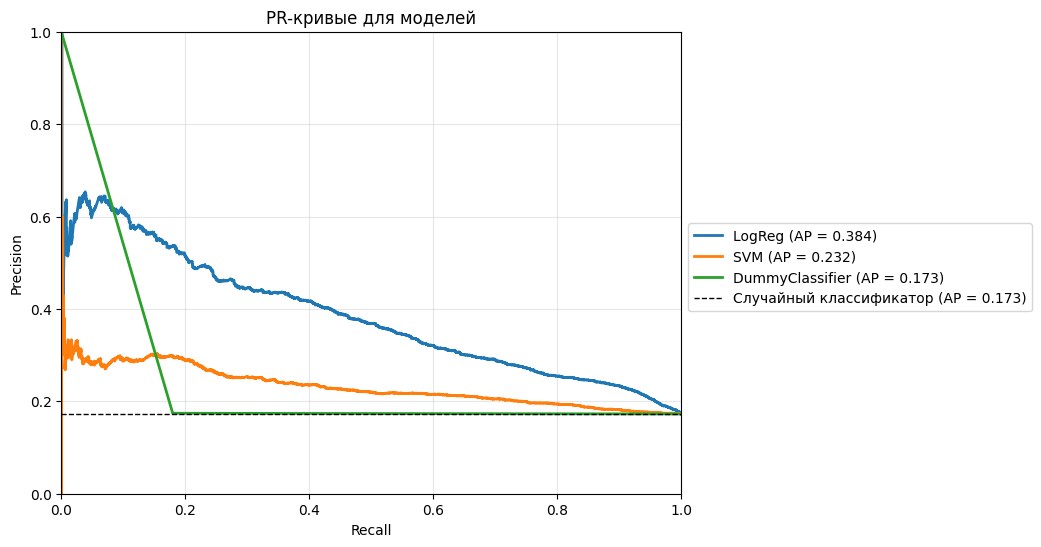

In [67]:
def show_pr_curve(y_test, y_pred_list, model_names_list):
    # Рассчитываем PR-кривые и PR-AUC для каждой модели
    assert len(y_pred_list) == len(model_names_list)

    pr_values = []

    for i in range(len(y_pred_list)):
        y_pred = y_pred_list[i][:,1]
        model_name = model_names_list[i]
        precision_a, recall_a, _ = precision_recall_curve(y_test, y_pred)
        pr_auc_a = average_precision_score(y_test, y_pred)
        pr_values.append({
            'model_name': model_name,
            'precision': precision_a,
            'recall': recall_a,
            'pr_auc': pr_auc_a,
        })

    # Построим график
    plt.figure(figsize=(8, 6))

    for pr_val in pr_values:
        plt.plot(
            pr_val['recall'],
            pr_val['precision'],
            label=f'{pr_val['model_name']} (AP = {pr_val['pr_auc']:.3f})', linewidth=2)

    baseline = sum(y_test) / len(y_test)
    plt.axhline(y=baseline, color='k', linestyle='--',
                label=f'Случайный классификатор (AP = {baseline:.3f})', linewidth=1)

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('PR-кривые для моделей')
    plt.legend(
        # loc='upper right',
        bbox_to_anchor=(1, 0.6), #upd: убрал за график, чтобы не перекрывало линии
    )
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.show()

pipeline_dummy.fit(X_train_val, y_train_val)

show_pr_curve(
    y_test,
    [y_pred_proba, y_pred_proba_final_svm, pipeline_dummy.predict_proba(X_test)],
    ['LogReg', 'SVM', 'DummyClassifier'],
)

Кривые PR отражают то, что LogReg справляется с задачей лучше, чем SVM. Однако качество обеиз моделей не значительно превосходит DummyClassifier.

#### 8.2 Посчитаем метрику калибровки
- Необходимые метрики:
  - PR-AUC.
  - Оценка Бриера.
  - Дополнительные метрики при необходимости.



In [68]:
brier_lr = brier_score_loss(
    y_test,
    y_pred_proba[:, 1],
)
brier_svm = brier_score_loss(
    y_test,
    y_pred_proba_final_svm[:, 1]
)

print(f'Brier score for Logistic Regression: {brier_lr:.4f}')
print(f'Brier score for SVM: {brier_svm:.4f}')

Brier score for Logistic Regression: 0.1263
Brier score for SVM: 0.1415


In [69]:
max(y_pred_proba_final_svm[:, 1])

np.float64(0.2919624216740151)

Логистическая регрессия лучше соответствует реальным вероятностям, вычисленным по доле положительного класса, по оценке Бриера, чем SVM.

#### 8.3 Анализ важности признаков

Проверим, какие признаки показывают наибольшую значимость для обучения. Будем рассматривать только Логистическую регрессию, так как она показывает лучшее качество результатов, чем SVM.

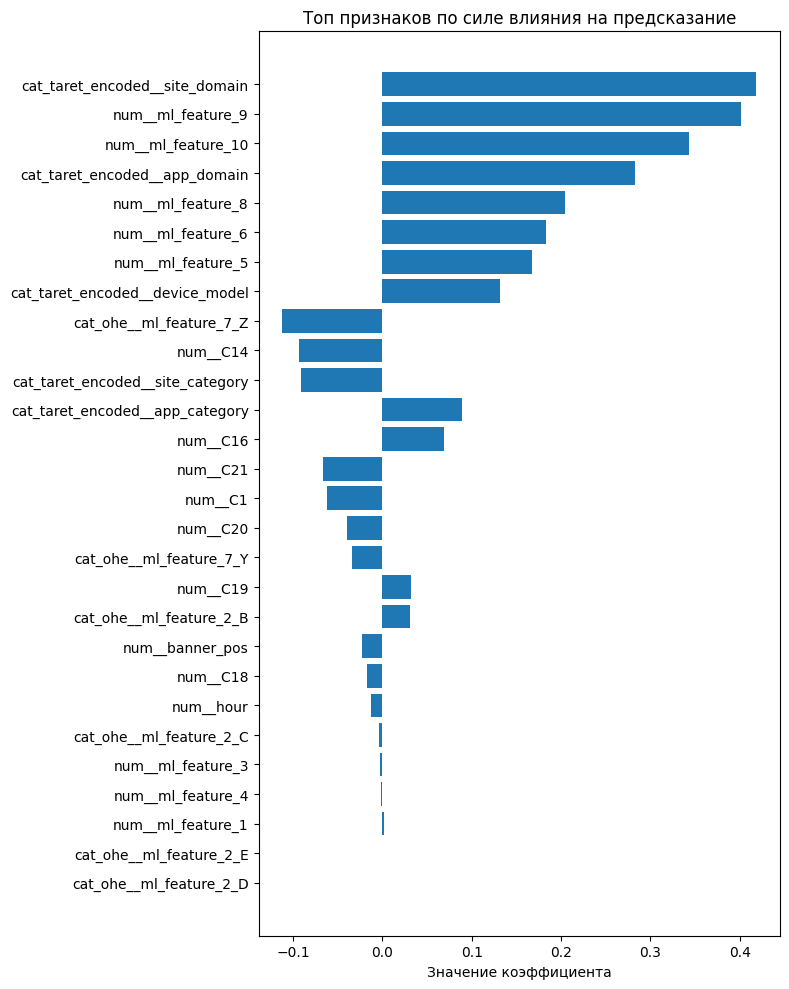

,feature,coefficient,abs_coefficient
0,cat_taret_encoded__site_domain,0.418622,0.418622
1,num__ml_feature_9,0.401850,0.401850
2,num__ml_feature_10,0.343301,0.343301
3,cat_taret_encoded__app_domain,0.282380,0.282380
4,num__ml_feature_8,0.204828,0.204828
5,num__ml_feature_6,0.182956,0.182956
6,num__ml_feature_5,0.167756,0.167756
7,cat_taret_encoded__device_model,0.131879,0.131879
8,cat_ohe__ml_feature_7_Z,-0.112030,0.112030
9,num__C14,-0.093501,0.093501


In [70]:
feature_importance(
    lr_final_pipeline['model'],
    lr_final_pipeline[:-1].get_feature_names_out(),
)['weights']


Топ-5 признаков по важности:
- site_domain
- ml_feature_9
- ml_feature_10
- app_domain
- ml_feature_8



Хорошо себя показывают признаки, которые ожидаемо связаны с площадкой (site_domain), с рекламным объявлением (app_domain).
Набор топовых выбранных признаков выглядит адекватно.

<a id="calibration"></a>
## 9. Калибровка модели

#### 9.1 Проверьте текущую калибровку
- Постройте калибровочную кривую, используйте `sklearn.calibration.calibration_curve`.
- Для обработки «сырых» значений SVC, нужно применить стандартную (необученную) сигмоиду для получения [0, 1].

Для визуализации калибровки модели построим калибровочную кривую.

In [71]:
lr_pipeline_calib = build_final_pipeline(define_lr_best())
lr_pipeline_calib.fit(X_train_val, y_train_val)
y_pred_proba_final_lr = lr_pipeline_calib.predict_proba(X_test)

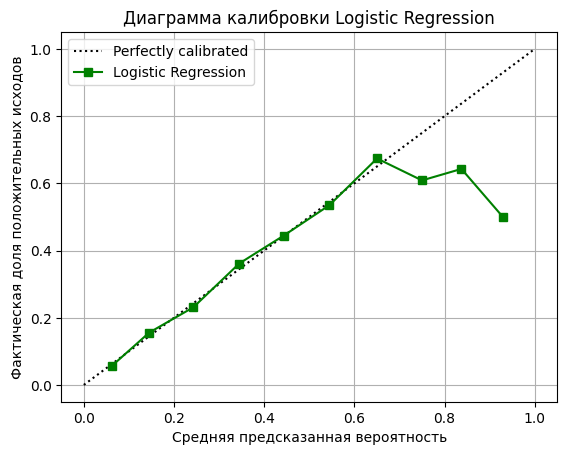

In [72]:
def display_calib_curve(model_name, y_test, y_pred_proba):
    y_pred_proba_ = y_pred_proba[:, 1] if len(y_pred_proba.shape) > 1 else y_pred_proba
    prob_true_lr, prob_pred_lr = calibration_curve(y_test, y_pred_proba_, n_bins=10, strategy='uniform')
    CalibrationDisplay(prob_true_lr, prob_pred_lr, y_test).plot(label=model_name, color='green')
    plt.title(f'Диаграмма калибровки {model_name}')
    plt.xlabel('Средняя предсказанная вероятность')
    plt.ylabel('Фактическая доля положительных исходов')
    plt.legend()
    plt.grid(True)
    plt.show()

display_calib_curve('Logistic Regression', y_test, y_pred_proba_final_lr)


Логрег имеет хорошую калибровку на низких вероятрностях, что согласуется с тем, что модель имеет высокие показатели точности и полноты на отрицательном классе.

После вероятности 0.6 модель считает себя самоуверенной и завышает предсказанные вероятности - это видно по смещению графика вправо.

Построим диаграмму калибровки для SVM. Для этого получим сырые предсказания модели. Чтобы этого достичь, небходимо указать параметр probability=False при создании модели, также пропустить выхлоп модели, полученный функцией decision_function, через сигмойду, которая преобразует сырые предсказания в вероятности, распределенные на интервале [0, 1].

In [73]:
# определим функцию sigmoid
def np_sigmoid(x):
    return 1 / (1 + np.exp(-x))

# обучим пайплайн SVM
svm_pipeline_raw = build_final_pipeline(define_svc_best(probability=False))
svm_pipeline_raw.fit(X_train_val, y_train_val)

# получим сырые предсказания модели на тесте
y_pred_proba_final_svm_raw = svm_pipeline_raw.decision_function(X_test)

# преобразуем сырые предсказания сигмойдой
y_pred_proba_final_svm_sigm = np_sigmoid(y_pred_proba_final_svm_raw)

# проверим, что преобразование через сигмойду изменила значения сырых предсказаний
print(
    f'min_sigm {min(y_pred_proba_final_svm_sigm)}',
    f'max_sigm {max(y_pred_proba_final_svm_sigm)}',
    f'min_raw {min(y_pred_proba_final_svm_raw)}',
    f'max_raw {max(y_pred_proba_final_svm_raw)}',
    sep='\n'
)

/Users/ngsmirnov/nikki/projects/practicum/sprint12_svm_prob_calib_ftr_slctn/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=3000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


min_sigm 0.4427181736908996
max_sigm 0.9237339430520047
min_raw -0.23013769296747255
max_raw 2.4941961135163964


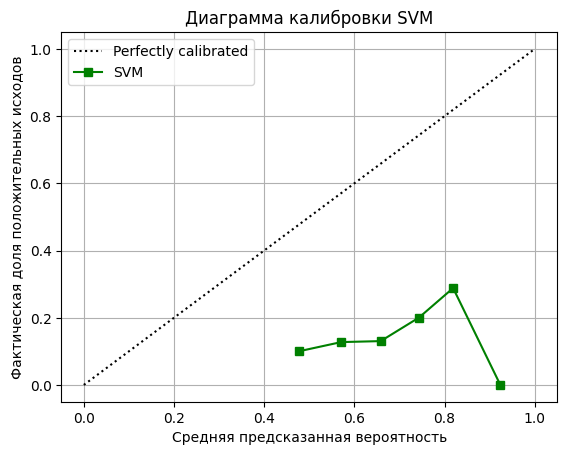

In [74]:
# рисуем кривую калибровки
display_calib_curve('SVM', y_test, y_pred_proba_final_svm_sigm)

Такая форма калибровочной кривой объясняется низким качеством модели SVM.

#### 9.2 Применим методы калибровки для финальной модели
- Используйте `CalibratedClassifierCV` с методом `'isotonic'`.
- **Важно:** используйте для процедуры отдельную калибровочную выборку!

Обучим финальную модель с калибровкой вероятностей изотонической регрессией.

In [75]:
lr_calibrated = CalibratedClassifierCV(
    estimator=build_final_pipeline(define_lr_best()),
    method='isotonic',
    ensemble=False,
    cv=skf,
)
svm_calibrated = CalibratedClassifierCV(
    estimator=build_final_pipeline(define_svc_best()),
    method='isotonic',
    ensemble=False,
    cv=skf,
)
# обучаем на тренировочных/валидационных данных
# CalibratedClassifierCV обучает LogReg внутри
# каждый фолд по очереди используется для калибровки, остальные - для обучения
lr_calibrated.fit(X_train_val, y_train_val)
svm_calibrated.fit(X_train_val, y_train_val)
print('Калибровка завершена')


/Users/ngsmirnov/nikki/projects/practicum/sprint12_svm_prob_calib_ftr_slctn/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=3000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/ngsmirnov/nikki/projects/practicum/sprint12_svm_prob_calib_ftr_slctn/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=3000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/ngsmirnov/nikki/projects/practicum/sprint12_svm_prob_calib_ftr_slctn/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=3000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/ngsmirnov/nikki/projects/practicum/sprint12_svm_prob_calib_ftr_slctn/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:305: Co

Калибровка завершена


/Users/ngsmirnov/nikki/projects/practicum/sprint12_svm_prob_calib_ftr_slctn/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=3000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(




#### 9.3 Сравните модели до и после калибровки
- Посчитайте оценки Бриера для моделей до и после калибровки.
- Дополнительно можете рассчитать ECE и MCE для моделей до и после калибровки.
- Визуализируйте калибровочные кривые для моделей до и после калибровки.

In [76]:
brier_score_calib_lr = brier_score_loss(y_test, lr_calibrated.predict_proba(X_test)[:, 1])
brier_score_calib_svm = brier_score_loss(y_test, svm_calibrated.predict_proba(X_test)[:, 1])
print(f'Brier Logistic Regression: {brier_score_calib_lr:.4f} (калиброванная), {brier_lr:.4f} (некалиброванная)')
print(f'Brier SVM: {brier_score_calib_svm:.4f} (калиброванная), {brier_svm:.4f} (некалиброванная)')


Brier Logistic Regression: 0.1261 (калиброванная), 0.1263 (некалиброванная)
Brier SVM: 0.1411 (калиброванная), 0.1415 (некалиброванная)


Оценка Бриера для калиброванной логистической регрессии немного улучшилась, но незначительно. Для SVM - таже незначительные улучшения.

Визуализируем калибровочные кривые для моделей до и после калибровки.

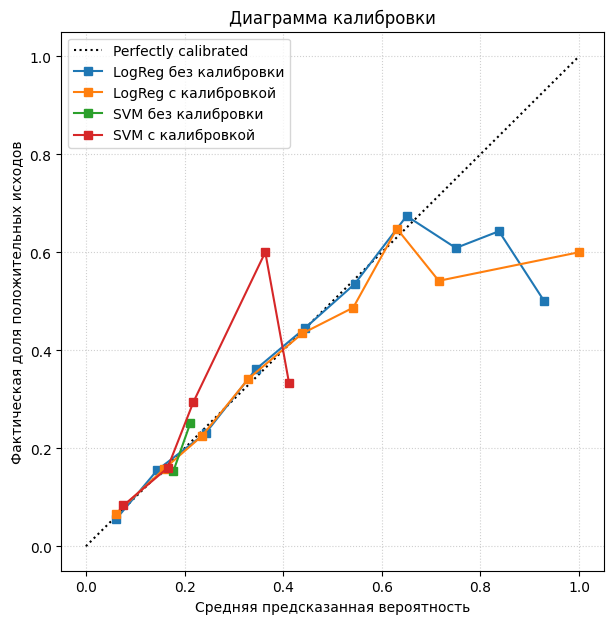

In [77]:
def display_calib_models(models_and_estimators, X_test, y_test):
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.grid(True, linestyle=':', alpha=0.6)
    color = 0
    for model_name, estimator in models_and_estimators.items():
        CalibrationDisplay.from_estimator(
            estimator,
            X_test,
            y_test,
            n_bins=10,
            name=model_name,
            ax=ax,
            color=f'C{color}'
        )
        color += 1
    plt.title(f'Диаграмма калибровки')
    plt.xlabel('Средняя предсказанная вероятность')
    plt.ylabel('Фактическая доля положительных исходов')
    plt.legend()
    plt.show()


display_calib_models({
        'LogReg без калибровки': lr_final_pipeline,
        'LogReg с калибровкой': lr_calibrated,
        'SVM без калибровки': svm_final_pipeline,
        'SVM с калибровкой': svm_calibrated,
    },
    X_test=X_test, y_test=y_test,
)

Визуально кривые калиброванная модель не сильно отличается от некалиброванной.

<a id="calibration-testing"></a>
## 10. Оценка качества калибровки

#### 10.1 Посчитайте метрики калибровки
- Оценка Бриера — средняя ошибка предсказанной вероятности.
- Дополнительная метрика ECE: среднее расхождение вероятностей.
- Дополнительная метрика MCE: максимальное расхождение вероятностей.



Напишем универсальную функцию для подсчета метрик калибровки:

In [78]:
def calc_calibration_error(error_type, y_true, y_prob, n_bins=10):
    """
    ВычисляетCalibration Error в зависимости от типа error_type:
    - ece - Expected Calibration Error
    - mce - Maximum Calibration Error
    - brier - Brier Score

    Args:
        y_true (np.array): Истинные метки классов (0 или 1).
        y_prob (np.array): Предсказанные вероятности для класса 1.
        n_bins (int): Количество интервалов (бинов) для разбиения вероятностей.

    Returns:
        float: Значение ошибки калибровки.
    """
    y_prob = y_prob[:, 1]
    if error_type == 'brier':
        return brier_score_loss(y_true, y_prob)

    # Создаем границы бинов, равномерно распределенные от 0 до 1.
    # Например, для n_bins=10, это будут [0.0, 0.1, 0.2, ..., 1.0].
    bins = np.linspace(0, 1, n_bins + 1)

    ece = 0  # Инициализируем общую ошибку калибровки.
    mce = 0  # Инициализируем максимальную ошибку калибровки.
    max_error = 0
    n = len(y_true)  # Общее количество примеров.


    # Итерируемся по каждому бину.
    for i, (bin_lower, bin_upper) in enumerate(zip(bins[:-1], bins[1:])):
        # Создаем логическую маску для отбора примеров, которые попадают в текущий бин.
        # Последний бин (i == n_bins - 1) включает правую границу, чтобы захватить
        # вероятность 1.0, остальные - нет.
        if i == n_bins - 1:
            mask = (y_prob >= bin_lower) & (y_prob <= bin_upper)
        else:
            mask = (y_prob >= bin_lower) & (y_prob < bin_upper)

        # Проверяем, есть ли в текущем бине хотя бы один пример.
        if np.sum(mask) > 0:
            bin_size = np.sum(mask)

            # Вычисляем среднюю предсказанную уверенность (confidence) для бина.
            bin_conf = np.mean(y_prob[mask])

            # Вычисляем среднюю точность (долю правильных ответов) в этом бине.
            bin_acc = np.mean(y_true[mask])

            # Вычисляем вклад текущего бина в общую ошибку.
            # Это абсолютная разница, умноженная на количество примеров в бине.
            diff = np.abs(bin_acc - bin_conf)
            contribution = diff * bin_size
            ece += contribution
            max_error = max(max_error, diff)


    # Возвращаем итоговое значение ECE, нормированное на общее количество примеров.
    return max_error if error_type == 'mce' else ece / n

Оценим качество калибровки с помощью метрик Brier score, Expected Calibration Error, Maximum Calibration Error:

In [79]:

calib_metrics = []
pipeline_dummy.fit(X_test, y_test)
name_by_model = {
    'LogReg': lr_final_pipeline,
    'LogReg (calib)': lr_calibrated,
    'SVM': svm_final_pipeline,
    'SVM (calib)': svm_calibrated,
    'Dummy': pipeline_dummy,
}
for name, model in name_by_model.items():
    y_pred_proba = model.predict_proba(X_test)
    calib_metrics.append({
        'model_name': name,
        'brier': calc_calibration_error('brier', y_test, y_pred_proba),
        'ece': calc_calibration_error('ece', y_test, y_pred_proba),
        'mce': calc_calibration_error('mce', y_test, y_pred_proba),
    })

pd.DataFrame(calib_metrics).round(4)


,model_name,brier,ece,mce
0,LogReg,0.1142,0.0210,0.1325
1,LogReg (calib),0.1261,0.0076,0.4000
2,SVM,0.1419,0.0218,0.0273
3,SVM (calib),0.1411,0.0127,0.2364
4,Dummy,0.2859,0.2859,0.8342


#### 10.2 Сравните модели до и после калибровки
- Выведите все метрики в одной таблице.
- Сделайте вывод о том, улучшила ли калибровка качество моделей.

In [80]:
final_metrics_lr = predict_and_score('LogReg', lr_final_pipeline, X_test, y_test)
final_metrics_lr_calib = predict_and_score('LogReg (calib)', lr_calibrated, X_test, y_test)
final_metrics_svm = predict_and_score('SVM', svm_final_pipeline, X_test, y_test)
final_metrics_svm_calib = predict_and_score('SVM (calib)', svm_calibrated, X_test, y_test)
final_metrics_dummy = predict_and_score('Dummy', pipeline_dummy, X_test, y_test)

all_metrics = [
    final_metrics_lr|calib_metrics[0],
    final_metrics_lr_calib|calib_metrics[1],
    final_metrics_svm|calib_metrics[2],
    final_metrics_svm_calib|calib_metrics[3],
    final_metrics_dummy|calib_metrics[4],
]
pd.DataFrame(all_metrics).round(4)

/Users/ngsmirnov/nikki/projects/practicum/sprint12_svm_prob_calib_ftr_slctn/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,model_name,pr_auc,precision,recall,f1,brier,ece,mce
0,LogReg,0.5143,0.7807,0.1563,0.2605,0.1142,0.0210,0.1325
1,LogReg (calib),0.3761,0.5758,0.1112,0.1865,0.1261,0.0076,0.4000
2,SVM,0.2290,0.1719,0.9930,0.2930,0.1419,0.0218,0.0273
3,SVM (calib),0.2246,0.0000,0.0000,0.0000,0.1411,0.0127,0.2364
4,Dummy,0.1716,0.1609,0.1575,0.1592,0.2859,0.2859,0.8342


Калиброванная модель логистической регрессии чуть хуже педсказывает по метрике PR-AUC (на 0.1), f1 при этом незначительно опускается (на 0.1). Отличный результат виден в метрике ожидаемой ошибки калибровки - ECE снизился с 0.02 до 0.008.

Несмотря на снижение PR-AUC в производственную эксплуатацию предпочтительно передавать калиброванную модель, так как в области применения модели особенно важны точные вероятностные оценки.

<a id="final-report"></a>
## 11. Финальный отчёт и выводы

### 11.1 Сведите все результаты в таблицу

Покажите:
- Характеристики базовой модели `DummyClassifier`.
- Характеристики финальной модели.
- Метрики до и после калибровки.
- Топ-5 самых важных признаков.


#### Метрики моделей на тестовой выборке

| Модель | PR-AUC | Precision | Recall | F1 | Brier | ECE | MCE |
|---|---|---|---|---|---|---|---|
| DummyClassifier | 0.1716 | 0.1609 | 0.1575 | 0.1592 | 0.2859 | 0.2859 | 0.8342 |
| LogReg (финальная) | 0.5143 | 0.7807 | 0.1563 | 0.2605 | 0.1142 | 0.0210 | 0.1325 |
| LogReg (калиброванная) | 0.3761 | 0.5758 | 0.1112 | 0.1865 | 0.1261 | 0.0076 | 0.4000 |
| SVM (финальная) | 0.2290 | 0.1719 | 0.9930 | 0.2930 | 0.1419 | 0.0218 | 0.0273 |
| SVM (калиброванная) | 0.2246 | 0.0000 | 0.0000 | 0.0000 | 0.1411 | 0.0127 | 0.2364 |

#### Параметры финальных моделей

| Параметр | LogReg | SVM |
|---|---|---|
| C | 0.12 | 0.1 |
| penalty | l1 | — |
| class_weight | None | balanced |
| solver | liblinear | — |
| kernel | — | linear |
| PR-AUC (CV) | 0.39297 | 0.19784 |

#### Топ-5 признаков по важности (коэффициенты LogReg)

| Место | Признак | Коэффициент |
|---|---|---|
| 1 | site_domain | 0.4186 |
| 2 | ml_feature_9 | 0.4019 |
| 3 | ml_feature_10 | 0.3433 |
| 4 | app_domain | 0.2824 |
| 5 | ml_feature_8 | 0.2048 |

### 11.2 Напишите выводы

Ответьте на вопросы:
- Улучшилось ли качество модели по сравнению с базовой?
- Какие признаки больше всего влияют на вероятность клика?
- Насколько хорошо модель откалибрована?
- Готова ли модель к использованию в продакшене?


#### Улучшилось ли качество модели по сравнению с базовой?

Да, качество финальной модели значительно превышает базовую линию `DummyClassifier`.

Логистическая регрессия с оптимальными параметрами (`C=0.12`, `penalty='l1'`, `solver='liblinear'`) достигла **PR-AUC = 0.5143** на тестовой выборке — это в **3 раза выше** базовой линии (PR-AUC = 0.1716). Brier Score снизился с 0.2859 (Dummy) до 0.1142, что говорит о существенно более точных вероятностных предсказаниях.

SVM с параметрами `C=0.1`, `class_weight='balanced'` показал PR-AUC = 0.2290 — лучше базовой линии, но значительно хуже логистической регрессии. Модель SVM демонстрирует экстремально высокий Recall (0.993), предсказывая почти все объекты как положительный класс, что делает её практически непригодной для реального использования.

**Победитель:** Логистическая регрессия.

#### Какие признаки больше всего влияют на вероятность клика?

По абсолютным значениям коэффициентов финальной модели логистической регрессии, наибольший вклад вносят:

1. **`site_domain`** (0.4186) — домен сайта-площадки. Наиболее важный признак: конкретная площадка размещения рекламы сильно определяет вероятность клика.
2. **`ml_feature_9`** (0.4019) — один из инженерных признаков advandex. Высокая важность указывает на то, что этот признак несёт значимую информацию о поведении пользователя.
3. **`ml_feature_10`** (0.3433) — второй по важности инженерный признак.
4. **`app_domain`** (0.2824) — домен приложения. Контекст приложения, в котором показывается реклама, существенно влияет на CTR.
5. **`ml_feature_8`** (0.2048) — третий значимый инженерный признак.

Таким образом, наибольшее влияние оказывают **контекстные признаки площадки** (`site_domain`, `app_domain`) и **инженерные признаки** advandex (`ml_feature_9`, `ml_feature_10`, `ml_feature_8`). Это логично: вероятность клика сильно зависит от того, на каком сайте и в каком приложении показывается реклама.

#### Насколько хорошо модель откалибрована?

Результаты калибровки неоднозначны:

**Логистическая регрессия** до калибровки уже имеет хорошую калибровку по ECE = 0.0210. После применения `CalibratedClassifierCV` с методом `isotonic` ECE улучшился до **0.0076** — это отличный результат, означающий, что предсказанные вероятности очень близки к реальным частотам. Однако PR-AUC при этом снизился с 0.5143 до 0.3761, а MCE вырос с 0.1325 до 0.4000.

**SVM** после калибровки полностью перестал предсказывать положительный класс (Precision = Recall = F1 = 0.0), что делает калиброванный SVM непригодным для использования.

**Вывод:** Для продакшена выбрана **калиброванная логистическая регрессия** (`lr_calibrated`), поскольку задача требует надёжных вероятностных оценок (а не только ранжирования), а ECE = 0.0076 обеспечивает высокое доверие к предсказанным вероятностям.

#### Готова ли модель к использованию в продакшене?

Модель **частично готова** к продакшену с рядом оговорок:

**Готово:**
- Модель сохранена в файл `adv_click_prediction_model_v1.0_2026_03_19.joblib` с метаданными (версия, дата, PR-AUC, список признаков)
- Работоспособность проверена: модель корректно загружается и выдаёт предсказания
- Калибровка обеспечивает надёжные вероятностные оценки (ECE = 0.0076)
- Пайплайн включает полную предобработку (кодирование, масштабирование), что исключает необходимость ручной предобработки при инференсе

**Ограничения:**
- PR-AUC = 0.3761 (калиброванная модель) — умеренное качество. При высоких требованиях к точности предсказаний модель нуждается в доработке
- Модель обучена на данных за 10 дней; при значительном дрейфе данных потребуется переобучение
- Recall = 0.1112 означает, что модель пропускает ~89% реальных кликов — это приемлемо для задач оптимизации ставок, но не для задач максимизации охвата

### 11.3 Рекомендации

- Какие возможности улучшения модели вы видите?

#### 1. Попробовать более мощные алгоритмы
Логистическая регрессия и линейный SVM - линейные модели, которые не улавливают нелинейные взаимодействия признаков. Рекомендуется попробовать:
- Gradient Boosting (XGBoost, CatBoost) - более мощьные алгоритмы, которые могут улавливать нелинейные взаимодействия признаков
- Random Forest - как промежуточный вариант с нелинейностью

#### 2. Расширить инженерию признаков
- Создать кросс-признаки между site_domain × app_domain, device_model × site_category и другими топовыми признаками
- Добавить временные признаки: день недели, час суток (уже есть hour, но можно категорию времени суток)

#### 3. Улучшить отбор признаков
- SequentialFeatureSelector с forward направлением отобрал 19 из 28 признаков. Стоит проверить backward направление и сравнить результаты

#### 4. Расширить данные
- Модель обучена на 50к записях за 10 дней. Увеличение объёма обучающих данных (больше дней, больше пользователей) должно улучшить обобщающую способность

#### 5. Улучшить калибровку
- Текущий MCE = 0.4000 для калиброванной модели высок - это означает, что в отдельных бинах вероятности сильно расходятся с реальными. Попробовать метод sigmoid вместо isotonic или Platt Scaling
- Увеличить cv в CalibratedClassifierCV для более стабильной калибровки

<a id="save-model"></a>
## 12. Сохранение модели для продакшена

### 12.1 Сохраните артефакты

Сохраните:
1. пайплайн предобработки данных `preprocessor`;
2. финальную модель `calibrated_model`;
3. информацию о выбранных признаках.



In [81]:
VERSION=1.0
date = datetime.now().strftime('%Y_%m_%d')
model_name = f"adv_click_prediction_model_v{VERSION}_{date}.joblib"

ALL_FEATURES = NUM_FEATURES_SELECTED + OHE_FEATURES_SELECTED + TARGET_ENCODED_FEATURES_SELECTED


metadata = {
    'model_version': f'{VERSION}',
    'training_date': f'{date}',
    'pr_auc': final_metrics_lr_calib['pr_auc'],
    'features': ALL_FEATURES,
}

joblib.dump(
    {
        'model': lr_calibrated,
        'metadata': metadata
    },
    model_name,
)

['adv_click_prediction_model_v1.0_2026_03_20.joblib']

### 12.2 Проверьте работоспособность вашего кода

- Загрузите сохранённые артефакты.
- Сделайте предсказания на новых данных.
- Убедитесь, что результаты совпадают.

Выведем проивольный объект из исходного датасета:

In [82]:
df.query('click == 1').head(10)

,click,hour,C1,banner_pos,site_domain,site_category,app_domain,app_category,device_model,device_conn_type,C14,C16,C18,C19,C20,C21,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1,0,1005,1,98572c79,f028772b,7801e8d9,07d7df22,31025cda,0,17614,50,2,1063,-1,33,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
5,1,0,1005,0,f3845767,28905ebd,7801e8d9,07d7df22,711ee120,0,15702,50,0,35,100084,79,-0.386621,D,-2.561220,1,-0.327084,0.997424,Y,-0.718630,0.063355,0.118050
9,1,0,1005,1,0a4015b2,335d28a8,7801e8d9,07d7df22,be74e6fe,0,18993,50,0,35,100105,157,-1.098406,D,6.310419,0,1.930692,-0.980213,Y,-0.354278,0.372335,0.321687
15,1,0,1005,0,f3845767,28905ebd,7801e8d9,07d7df22,5096d134,0,15701,50,0,35,-1,79,-0.353895,D,-1.565348,1,0.479683,-0.999994,X,1.021148,0.474386,0.229159
16,1,0,1005,1,98572c79,f028772b,7801e8d9,07d7df22,8a4875bd,0,15699,50,0,35,100084,79,-0.747515,C,1.673000,1,0.501776,-0.955640,X,-0.045894,-0.266548,0.068112
18,1,0,1005,0,f3845767,28905ebd,7801e8d9,07d7df22,ecb851b2,0,15708,50,0,35,100084,79,2.954963,D,-6.714817,1,-1.132956,-0.881895,Y,-0.250512,0.016067,0.366751
36,1,0,1005,1,98572c79,f028772b,7801e8d9,07d7df22,e9b8d8d7,0,17614,50,2,1063,100083,33,0.124439,B,8.848026,0,-0.139464,-0.138445,X,-0.191390,1.444613,0.320121
38,1,0,1005,0,c4e18dd6,50e219e0,2347f47a,0f2161f8,1f0bc64f,2,452,50,3,1319,100130,15,0.719692,A,-9.101188,0,1.409596,0.185627,Z,-0.430544,-0.053474,0.201982
42,1,0,1005,0,f3845767,28905ebd,7801e8d9,07d7df22,1f0bc64f,0,15703,50,0,35,-1,79,1.340590,D,-7.646071,1,0.378286,-0.025123,Z,1.068202,0.693988,0.156967
43,1,0,1005,0,61eb5bc4,f028772b,7801e8d9,07d7df22,3bd9e8e7,0,18993,50,0,35,-1,157,-1.105691,E,-4.670411,1,-0.430650,-0.851774,Y,-0.492801,-0.569444,0.384929


In [83]:
print(df.iloc[15].to_json(indent=4))

{
    "click":1,
    "hour":0,
    "C1":1005,
    "banner_pos":0,
    "site_domain":"f3845767",
    "site_category":"28905ebd",
    "app_domain":"7801e8d9",
    "app_category":"07d7df22",
    "device_model":"5096d134",
    "device_conn_type":0,
    "C14":15701,
    "C16":50,
    "C18":0,
    "C19":35,
    "C20":-1,
    "C21":79,
    "ml_feature_1":-0.3538954164,
    "ml_feature_2":"D",
    "ml_feature_3":-1.5653475123,
    "ml_feature_4":1,
    "ml_feature_5":0.4796829171,
    "ml_feature_6":-0.9999940705,
    "ml_feature_7":"X",
    "ml_feature_8":1.0211482648,
    "ml_feature_9":0.4743858801,
    "ml_feature_10":0.2291585793
}


In [84]:
# Проверка работоспособности модели:
loaded_model = joblib.load(f'{model_name}')

user = pd.DataFrame([
    {
    "click":1,
    "hour":0,
    "C1":1005,
    "banner_pos":0,
    "site_domain":"f3845767",
    "site_category":"28905ebd",
    "app_domain":"7801e8d9",
    "app_category":"07d7df22",
    "device_model":"5096d134",
    "device_conn_type":0,
    "C14":15701,
    "C16":50,
    "C18":0,
    "C19":35,
    "C20":-1,
    "C21":79,
    "ml_feature_1":-0.3538954164,
    "ml_feature_2":"D",
    "ml_feature_3":-1.5653475123,
    "ml_feature_4":1,
    "ml_feature_5":0.4796829171,
    "ml_feature_6":-0.9999940705,
    "ml_feature_7":"X",
    "ml_feature_8":1.0211482648,
    "ml_feature_9":0.4743858801,
    "ml_feature_10":0.2291585793
}
])

proba = loaded_model['model'].predict_proba(user)[:, 1]
print(f'Вероятность клика пользователя: {proba[0]:.2%}')

Вероятность клика пользователя: 33.44%
